# Семинар 5. МНК. Аппроксимация зашумлённых данных

*Версия от 01.09.2026*

*Внимание! Семинар содержит интерактивные демонстрации. На сайте они представлены в статическом виде. Для работы интерактивных элементов необходимо скачать страницу в формате ipynb и запустить ipynb-файл локально.*

# Часть первая — Метод наименьших квадратов

*Перед изучением этой части семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 6](https://www.youtube.com/live/BUTUuvs724M?si=Dflbqjl2AdyGauPC&t=3).*

Предполагается, что читатель знает

* определение невязки $\textbf{r}$ для случая СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$,
* определение детерминанта Вандермонда,
* определение и смысл числа обусловленности.

До сих пор мы рассматривали СЛАУ, в которых количество уравнений $n$ совпадало с количеством неизвестных $m$. Однако на практике встречаются и **переопределённые СЛАУ**. В них число уравнений больше числа неизвестных: $n>m$. Такие СЛАУ мы по-прежнему будем записывать в векторно-матричной форме:

$$\textbf{A}\textbf{x}=\textbf{f}.$$

Здесь $\textbf{x}$ и $\textbf{f}$ — векторы длин $m$ и $n$ соответственно, $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ — **прямоугольная** матрица.

Вообще говоря, **переопределённая СЛАУ не имеет классического решения**. Это означает, что в общем случае не существует такой совокупности из $m$ чисел, подстановка которой во все $n$ уравнений СЛАУ обратила бы **каждое** уравнение в верное равенство. В справедливости сделанного утверждения легко убедиться на простом примере. Пусть СЛАУ содержит две неизвестных: $x$ и $y$ — и пять уравнений вида

$$a_ix+b_iy=c_i,\quad i=1,\,2,\,\dots,\, 5.$$

Известно, что в некоторой прямоугольной декартовой системе координат на плоскости каждое уравнение задаёт прямую. Значит, решение рассматриваемой СЛАУ сводится к отысканию точки плоскости, в которой пересекались бы **все** пять прямых. Очевидно, что такой точки может и не существовать. Представим себе, что пять прямых случайно "бросают" на плоскость, а потом проверяют, не пересекаются ли эти прямые в общей точке. Понятно, что вероятность существования общей точки пересечения очень мала. Аналогичный пример можно привести и для трёхмерного случая, рассматривая общую точку пересечения нескольких **произвольных** плоскостей.

Итак, классического решения переопределённой СЛАУ обычно не существует. Можно, однако, поставить задачу отыскания некоторого набора из $m$ чисел, который в каком-то смысле мог бы заменить собой несуществующее классическое решение. Эта задача оказывается важной с точки зрения практики. Её анализ приводит к понятию **обобщённого решения СЛАУ** и **методу наименьших квадратов** (далее — МНК).

Мы начнём с формального изложения МНК, а затем покажем, как применяется этот метод для решения чрезвычайно распространённой задачи **линейной регрессии**.

## Решение переопределённых СЛАУ с помощью МНК

**Определение 1.** Пусть $\textbf{B}$ — симметричная положительно определённая матрица порядка $n$, а $\textbf{x},\,\textbf{y}\in \mathbb{R}^n$. *Скалярным произведением с весовой матрицей* $\textbf{B}$ назовём число

$$(\textbf{x},\textbf{y})_\textbf{B}=(\textbf{B}\textbf{x},\textbf{y}).$$

Легко убедиться в том, что величина $(\textbf{x},\textbf{y})_\textbf{B}$ удовлетворяет аксиомам скалярного произведения. Более того, можно показать, что в пространстве $\mathbb{R}^n$ **любое скалярное произведение может быть получено из стандартного скалярного произведения $(\,\cdot\,,\,\cdot\,)$ подбором некоторой весовой матрицы**.

**Определение 2.** Пусть $\textbf{A}\textbf{x}=\textbf{f}$ — переопределённая СЛАУ с матрицей $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$. *Целевым функционалом, соответствующим переопределённой СЛАУ,* будем называть квадратичную форму

$$\Phi(\textbf{x})=(\textbf{A}\textbf{x}-\textbf{f},\textbf{A}\textbf{x}-\textbf{f})_\textbf{B}.$$

В силу определения 1 очевидно, что $\Phi(\textbf{x})=(\textbf{B}\textbf{r},\textbf{r})$, где $\textbf{r}$ — невязка.

**Определение 3.** *Обобщённым решением переопределённой СЛАУ* $\textbf{A}\textbf{x}=\textbf{f}$ с матрицей $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ называется вектор $\textbf{u}\in\mathbb{R}^m$, доставляющий минимум целевому функционалу, соответствующему данной СЛАУ:

$$\textbf{u}=\operatorname{argmin}\Phi(\textbf{x}).$$

Таким образом, задача поиска обобщённого решения СЛАУ сводится к задаче минимизации некоторого квадратичного функционала. В простейшем случае, когда в качестве весовой матрицы выбрана единичная матрица ($\textbf{B}=\textbf{E}$), функционал $\Phi(\textbf{x})$ можно переписать так:

$$\Phi(\textbf{x})=(\textbf{A}\textbf{x}-\textbf{f},\textbf{A}\textbf{x}-\textbf{f})=\sum\limits_{i=1}^n r_i^2=\sum\limits_{i=1}^n\bigg(\sum\limits_{j=1}^{m} a_{ij}x_j-f_i\bigg)^2.$$

Иначе говоря, **мининизации подлежит сумма квадратов отклонений** величин $f_i$ от величин $\sum\limits_{j=1}^{m} a_{ij}x_j$. Именно поэтому соответствующий метод решения (переопределённой) СЛАУ называют "методом наименьших квадратов".

Продолжая рассмотрение частного случая $\textbf{B}=\textbf{E}$, заметим, что

$$\Phi(\textbf{x})=\sum\limits_{i=1}^n\bigg(\sum\limits_{j=1}^m a_{ij}x_j\bigg)^2-2\sum\limits_{i=1}^nf_i\sum\limits_{j=1}^m a_{ij}x_j+\sum\limits_{i=1}^nf_i^2,$$

поэтому

$$\frac{\partial\Phi}{\partial x_k}=2\sum\limits_{i=1}^n\sum\limits_{j=1}^ma_{ik}a_{ij}x_j-2\sum\limits_{i=1}^n a_{ik}f_i.$$

Иначе:

$$\text{grad}\,\Phi(\textbf{x})=2\textbf{A}^\text{T}\textbf{A}\textbf{x}-2\textbf{A}^\text{T}\textbf{f}.$$

Необходимым условием существования минимума функции многих переменных в точке $\textbf{x}$ является, как известно, равенство нулю градиента в этой точке. В рассматриваемом случае это условие приводит к СЛАУ

$$\textbf{A}^\text{T}\textbf{A}\textbf{x}=\textbf{A}^\text{T}\textbf{f}$$

(она уже не является переопределённой). То, что соответствующая стационарная точка является именно минимумом, следует из вида функционала $\Phi(\textbf{x})$.

Таким образом, при $\textbf{B}=\textbf{E}$ решение переопределённой СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ с помощью МНК сводится к решению СЛАУ $\textbf{A}^\text{T}\textbf{A}\textbf{x}=\textbf{A}^\text{T}\textbf{f}$ (симметризованной по Гауссу). Поскольку матрица $\textbf{A}^\text{T}\textbf{A}$ положительно определена, она не является вырожденной, так что у симметризованной СЛАУ существует единственное решение.

В общем случае произвольной весовой матрицы $\textbf{B}$ справедлива следующая теорема.

**Теорема 1.** Пусть матрица $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ имеет ранг $m$ ($n>m$). Тогда существует единственное *обобщённое* решение $\textbf{u}\in\mathbb{R}^m$ переопределённой СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$. Вектор $\textbf{u}$ может быть найден как *классическое* решение СЛАУ

$$\textbf{A}^\text{T}\textbf{B}\textbf{A}\textbf{x}=\textbf{A}^\text{T}\textbf{B}\textbf{f}$$

с произвольной весовой матрицей $\textbf{B}\in\text{Mat}_{n\times n}(\mathbb{R})$.

На практике матрица $\textbf{B}$ часто выбирается диагональной, так что целевой функционал принимает вид

$$\Phi(\textbf{x})=\sum\limits_{i=1}^m b_ir_i^2.$$

Коэффициенты $b_i>0$ определяют веса соответствующих компонент невязки и в связи с этим называются **весовыми коэффициентами**. Подбор этих коэффициентов (как, впрочем, и выбор матрицы $\textbf{B}$ в общем случае) находится в руках исследователя.

Заметим, что умножение $i$-го уравнения исходной СЛАУ на некоторое число $c_i\neq 0$ эквивалентно введению в целевой функционал веса $b_i=c_i^2$. Очевидно, что при этом меняется обобщённое решение переопределённой СЛАУ (в случае же "обычной" СЛАУ с классическим решением умножение уравнений на ненулевые константы не меняет решения).

Итак, теорема 1 сводит задачу нахождения обобщённого решения переопределённой СЛАУ с матрицей $\textbf{A}$ к решению СЛАУ с матрицей $\textbf{C}=\textbf{A}^\text{T}\textbf{B}\textbf{A}$, у которой число уравнений и число неизвестных совпадают. Конечно, при больших $m$ решение второй СЛАУ не ищется вручную — используется некоторый численный метод. Как обычно, выбирается метод, позволяющий получить решение с нужной точностью за наименьшее время. Если $m$ велико, то, как правило, применяется какой-то итерационный метод. Это особенно легко в случаях, когда весовая матрица $\textbf{B}$ подобрана так, чтобы матрица $\textbf{C}$ оказалась близка к единичной (и, соответственно, хорошо обусловленной).

## Задача 1


Найти обобщённое решение переопределённой СЛАУ

$$\begin{cases}
    x+y=1, \\
    2x+y=2, \\
    x+2y=3
  \end{cases}$$

с помощью МНК.

**Решение.** Пусть сначала весовая матрица $\textbf{B}$ совпадает с единичной: $\textbf{B}=\textbf{E}$. Проведём симметризацию Гаусса:

$$\textbf{A}=
  \begin{pmatrix}
    1 & 1 \\
    2 & 1 \\
    1 & 2
  \end{pmatrix},\quad
  \textbf{f}=
  \begin{pmatrix}
    1 \\
    2 \\
    3
  \end{pmatrix},\quad
  \textbf{A}^\text{T}\textbf{A}=
  \begin{pmatrix}
    6 & 5 \\
    5 & 6
  \end{pmatrix},
  \quad
  \textbf{A}^\text{T}\textbf{f}=
  \begin{pmatrix}
    8 \\
    9
  \end{pmatrix}.$$

Полученная СЛАУ

$$\begin{cases}
    6x + 5y = 8,\\
    5x + 6y = 9
  \end{cases}$$

имеет решение

$$x=\frac{3}{11}=0,(27),\quad y=\frac{14}{11}=1,(27).$$

Это и есть искомое обобщённое решение переопределённой СЛАУ.

Предположим теперь, что весовая матрица диагональна: $\textbf{B}=\text{diag}(b_1, b_2, b_3)$, причём $b_i>0$. Тогда

$$\textbf{A}^\text{T}\textbf{B}\textbf{A}=
  \begin{pmatrix}
    b_1+4b_2+b_3 & b_1+2b_2+2b_3 \\
    b_1+2b_2+2b_3 & b_1+b_2+4b_3
  \end{pmatrix},
  \quad
  \textbf{A}^\text{T}\textbf{B}\textbf{f}=
  \begin{pmatrix}
    b_1+4b_2+3b_3 \\
    b_1+2b_2+6b_3
  \end{pmatrix}.$$

Обобщённое решение приобретает вид:

$$x=\frac{b_1b_2-b_1b_3+3b_2b_3}{b_1b_2+b_1b_3+9b_2b_3},\quad y=\frac{2b_1b_3+12b_2b_3}{b_1b_2+b_1b_3+9b_2b_3}.$$

Дадим решению задачи графическую интерпретацию. На плоскости $(x,y)$ построим три прямые, заданные уравнениями исходной СЛАУ, и отметим точки их попарных пересечений. Координаты этих точек получаются как решения следующих трёх СЛАУ:

$$\begin{cases}
    x + y = 1,\\
    2x + y = 2;
  \end{cases}\quad
  \begin{cases}
    x + y = 1,\\
    x + 2y = 3;
  \end{cases}\quad
  \begin{cases}
    2x + y = 2,\\
    x + 2y = 3.
  \end{cases}$$

Соответствующие решения имеют вид

  $$\begin{cases}
    x = 1,\\
    y = 0;
  \end{cases}\quad
  \begin{cases}
    x = -1,\\
    y = 2;
  \end{cases}\quad
  \begin{cases}
    x = 1/3,\\
    y = 4/3.
  \end{cases}$$

Помимо этих точек отметим также точку, отвечающую найденному обобщённому решению, и выведем на печать её координаты:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, FloatSlider

b1_w = FloatSlider(min=0, max=100, step=0.5, value=1)
b2_w = FloatSlider(min=0, max=100, step=0.5, value=1)
b3_w = FloatSlider(min=0, max=100, step=0.5, value=1)

def graph(b1: float, b2: float, b3: float):
    # проверка на зануление более одного параметра
    if [b1, b2, b3].count(0) >=2:
        print("Не следует занулять более одного параметра!")
        return

    fig, ax = plt.subplots()

    # первая прямая: x + y = 1
    x1 = [-1 - 0.25, 1 + 0.25]
    line_1= np.vectorize(lambda xi: 1 - xi)
    y1 = line_1(x1)
    ax.plot(x1, y1, lw=2.0, c='b')

    # вторая прямая: 2x + y = 2
    x2 = [1/3 - 0.15, 1 + 0.15]
    line_2= np.vectorize(lambda xi: 2 - 2*xi)
    y2 = line_2(x2)
    ax.plot(x2, y2, lw=2.0, c='r')

    # третья прямая: x + 2y = 3
    x3 = [-1 - 0.25, 1/3 + 0.25]
    line_3= np.vectorize(lambda xi: (3 - xi) / 2)
    y3 = line_3(x3)
    ax.plot(x3, y3, lw=2.0, c='k')

    # три точки попарных пересечений
    ax.scatter(1, 0, s=75, c='yellow', ec='k', zorder=2)
    ax.scatter(-1, 2, s=75, c='yellow', ec='k', zorder=2)
    ax.scatter(1/3, 4/3, s=75, c='yellow', ec='k', zorder=2)

    # точка, соответствующая обобщённому решению
    x_gen = (b1*b2 - b1*b3 + 3*b2*b3) / (b1*b2 + b1*b3 + 9*b2*b3)
    y_gen = (2*b1*b3 + 12*b2*b3) / (b1*b2 + b1*b3 + 9*b2*b3)
    ax.scatter(x_gen, y_gen, s=75, c='lime', ec='k', zorder=2)

    ax.set_xlim( (-2, 2) )

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

    plt.title("Обобщённое решение переопределённой СЛАУ")
    plt.show()

    print("Обобщённое решение: ({:.4f}, {:.4f})".format(x_gen, y_gen))

interact(graph, b1=b1_w, b2=b2_w, b3=b3_w);

interactive(children=(FloatSlider(value=1.0, description='b1', step=0.5), FloatSlider(value=1.0, description='…

Жёлтым цветом на построенном графике выделены точки попарных пересечений прямых, а зелёным цветом — точка, отвечающая обобщённому решению. При увеличении веса той или иной компоненты невязки зелёная точка смещается к соответствующей прямой (если увеличивается коэффициент $b_1$ — к первой прямой, $b_2$ — ко второй, $b_3$ — к третьей). Это связано с тем, что в целевом функционале начинает доминировать компонента невязки, пропорциональная расстоянию от зелёной точки до выбранной прямой, и, следовательно, уменьшение именно этой компоненты (этого расстояния) будет наиболее сильно уменьшать целевой функционал $\Phi(\textbf{x})$.

**Упражнение 1.** Если положить какой-то **один** из весовых коэффициентов $b_i$ равным нулю, то в приведённой выше демонстрации зелёная точка совпадёт с одной из жёлтых. Объяснить это явление.

## Линейная регрессия

Изложенный выше МНК часто применяется на практике в качестве простейшего метода **регрессионного анализа**. Его широко используют в самых разных науках: физике, химии, биологии, экономике, социологии и др. Дальнейшее рассмотрение мы будем вести "на физическом языке".

Пусть некоторая физическая величина $y$ является (вообще говоря, неизвестной) функцией другой физической величины $x$: $y=y(x)$. Предположим, что в ходе некоторого эксперимента величина $x$ принимает значения из конечного набора $\{x_i\}_{i=1}^n$ (все $x_i$ считаем **различными**) и при каждом $x_i$ измеряется значение $y_i=y(x_i)$. Таким образом, результатом эксперимента является множество пар $\big\{(x_i, y_i)\big\}_{i=1}^n$.

Пусть для наблюдаемого в рассматриваемом эксперименте физического явления предложена модель, из которой следует, что зависимость $y$ от $x$ должна выражаться функцией

$$y=F(x; w_1,w_2,\dots , w_m)\equiv F(x; \textbf{w}).$$

Здесь $w_j$ — некоторые параметры, записанные для удобства в виде вектора $\textbf{w}$. Тогда, согласно результатам эксперимента,

$$y_i=F(x_i; \textbf{w}),\quad i=1,\,2,\,\dots,\,n.$$

Эти $n$ равенств можно рассматривать как систему уравнений на $m$ величин $w_j$. Как правило, $n\gg m$, т.е. система оказывается переопределённой, и поэтому найти её классическое решение не представляется возможным. Вместо этого ставится задача определить значения параметров $w_j$ из каких-то иных соображений — искать не классическое, а обобщённое решение переопределённой системы. Естественно требовать, чтобы функция $F=F(x;\textbf{w})$ с выбранными параметрами $w_j$ была **в некотором смысле близка** к неизвестной функции $y=y(x)$. Критерий близости можно формулировать по-разному. В простейшем случае можно подбирать параметры $w_j$ так, чтобы сумма квадратов отклонений величин $F(x_i; \textbf{w})$ от значений $y_i$ была наименьшей из возможных:

$$\Phi(\textbf{w})=\sum\limits_{i=1}^n\big(F(x_i; \textbf{w})-y_i\big)^2\quad\to\quad\min.$$

Поиск параметров, удовлетворяющих этому условию (или какому-либо другому критерию близости функций $F$ и $y$), является очень важной задачей с точки зрения физики: найденные по результатам эксперимента значения параметров можно будет сравнить с теоретическими предсказаниями и, таким образом, сделать выводы о применимости использованной модели явления. Также можно исследовать, насколько сильно меняются параметры $w_j$ в зависимости от рассматриваемого набора экспериментальных данных (выборки), по которому эти параметры находятся. Малое отличие совокупностей параметров, найденных по разным выборкам, будет указывать на применимость модели. Большое отличие будет говорить в пользу гипотезы о неприменимости модели.

В случаях, подобных описанному, часто говорят о **задаче построения регрессии** (от лат. regressio — движение назад, возвращение; термин введён Ф. Гальтоном в 1885 г.). Подчеркнём, что термин "регрессия" обычно применяется в математической статистике и смежных дисциплинах (в анализе данных, машинном обучении и пр.), а не в вычислительной математике. Строгая формулировка задачи регрессии тоже даётся в статистических терминах с учётом, например, того обстоятельства, что обе величины: $y$ и $x$ — являются случайными и характеризуются некоторыми распределениями. Статистическими методами исследуется и качество модели, полученной после решения системы уравнений на параметры $w_j$. Подробно всех этих вопросов мы касаться не будем (для их изучения следует обратиться к курсам математической статистики).

Метод построения регрессии, основанный на минимизации выписанного выше функционала $\Phi(\textbf{w})$, называется **методом наименьших квадратов** (Least Squares method — LS), по аналогии с ранее изложенным методом решения переопределённых СЛАУ. Для функционала $\Phi=\Phi(\textbf{w})$ часто используют обозначение $\text{RSS}=\text{RSS}(\textbf{w})$, образованное от английского термина "Residual Sum of Squares" (сумма квадратов отклонений).

Хотя название "МНК" относится и к методу регрессии, и к методу решения переопределённых СЛАУ, следует чётко понимать различие между этими двумя методами. В первом случае речь идёт о минимизации функционала $\text{RSS}$, который **может быть и нелинейным по параметрам** $w_j$ (в этом случае говорят о **нелинейном МНК**, или NLLS-методе — от английского Non-Linear Least Squares); другими словами, ставится довольно общая задача оптимизации. Во втором же случае под методом МНК понимается метод решения существенно линейной задачи — переопределённой СЛАУ (и тогда говорят о **линейном МНК**, или LLS-методе — от английского Linear Least Squares). Понятно, что линейность или нелинейность задачи регрессии определяется видом функции $F$. Если она нелинейна по параметрам $w_j$ (т.е. строится **нелинейная регрессионная модель**), то пользуются нелинейным МНК. Если же имеет место наиболее распространённый и простой случай линейной зависимости $F$ от $w_j$, то **регрессия является линейной** и регрессионный МНК, как мы увидим, совпадает с МНК, использующимся для решения переопределённых СЛАУ. Подчеркнём, что здесь играет роль вид функции $F$ **относительно параметров** $w_j$, **а не относительно переменной** $x$ (или совокупности переменных $x_k$, если их несколько, как в случае **множественной регрессии**). Так, регрессионные модели

$$F=w_1 + w_2 x + w_3 x^2,\quad F=w_1 + w_2 \ln x$$

линейны, в то время как регрессионные модели

$$F=\frac{1}{w_1 + w_2 x},\quad F=w_1 + w_2 e^{w_3x}$$

— нет.

Далее мы рассмотрим решение задачи линейной регрессии с помощью МНК. Мы намеренно не будем углубляться в статистическую сторону вопроса и пользоваться специфической терминологией, часто применяемой в курсах анализа данных (выборки, объекты и признаки, целевые и предикторные переменные и т.п.). Наша цель состоит лишь в том, чтобы дать пример реальной задачи, в которой возникают переопределённые СЛАУ.

Кроме того, мы не будем подробно обсуждать нелинейный МНК, так как для этого потребовалось бы предварительно изучать методы решения задач оптимизации. Традиционно об этих методах в курсе вычислительной математики даётся лишь общее представление, а подробности изучаются в специальных курсах.

Итак, имеем систему из $n$ уравнений на $m$ величин $w_j$:

$$y_i=F(x_i; \textbf{w}),\quad i=1,\,2,\,\dots,\,n.$$

В предположении линейности регрессионной модели можно написать следующее равенство:

$$F(x;\textbf{w})=\sum\limits_{j=1}^m w_j\varphi_j(x).$$

Здесь $\varphi_j(x)$ — некоторые функции. Их обычно называют **базисными функциями** (смысл этого названия выяснится из дальнейшего), а всю выписанную сумму называют **обобщённым полиномом**. Вектор $\textbf{w}$ в последней формуле называется **вектором весов**. Подчеркнём, что базисные функции могут быть и **нелинейными** по $x$.

Запишем $n$ уравнений $y_i=F(x_i; \textbf{w})$ в случае линейной модели:

$$\sum\limits_{j=1}^m w_j\varphi_j(x_i)=y_i,\quad i=1,\,2,\,\dots,\, n.$$

Образуем $m$ столбцов

$$\boldsymbol{\varphi}_j=\big(\varphi_j(x_1),\,\varphi_j(x_2),\,\dots,\,\varphi_j(x_n)\big)^\text{T},\quad j=1,\,2,\,\dots,\,m.$$

Имеем равенство:

$$\sum\limits_{j=1}^m w_j\boldsymbol{\varphi}_j=\textbf{y}.$$

Как известно, умножение матрицы на вектор сводится к составлению линейной комбинации из столбцов матрицы с коэффициентами, равными компонентам вектора. Поэтому последнюю формулу можно представить в виде переопределённой СЛАУ

$$\textbf{G}_\varphi\textbf{w}=\textbf{y},$$

где $\textbf{G}_\varphi$ — матрица размера $n\times m$, составленная из столбцов $\boldsymbol{\varphi}_j$, т.е.

$$\textbf{G}_\varphi =(g_{ij}),\quad g_{ij}=\varphi_j(x_i);\quad i=1,\,2,\,\dots,\,n;\quad j=1,\,2,\,\dots,\,m,\quad n\gg m.$$

Целевой функционал $\Phi$, соответствующий этой СЛАУ (см. определение 2), совпадает с функционалом $\text{RSS}$ рассматриваемой регрессионной модели по построению. Отсюда следует, что для нахождения вектора весов $\textbf{w}$ достаточно решить полученную переопределённую СЛАУ в обобщённом смысле. Для этого, согласно теореме 1, в предположении **линейной независимости** столбцов $\boldsymbol{\varphi}_j$ надо найти (классическое) решение СЛАУ

$$\textbf{G}_\varphi^\text{T}\textbf{B}\textbf{G}_\varphi \textbf{w}=\textbf{G}_\varphi^\text{T}\textbf{B}\textbf{y}.$$

Полагая для простоты $\textbf{B}=\textbf{E}$, приходим к СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$  с матрицей

$$\boldsymbol{\Gamma}=\textbf{G}_\varphi^\text{T}\textbf{G}_\varphi=(\gamma_{kl}),\quad\gamma_{kl}=\sum\limits_{i=1}^n\varphi_k(x_i)\varphi_l(x_i)\equiv (\boldsymbol{\varphi}_k,\boldsymbol{\varphi}_l),\quad k,\,l=1,\,2,\,\dots,\,m$$

и правой частью

$$\textbf{g}=\textbf{G}_\varphi^\text{T}\textbf{y},\quad g_k=\sum\limits_{i=1}^n\varphi_k(x_i)y_i\equiv (\boldsymbol{\varphi}_k,\textbf{y}),\quad k=1,\,2,\,\dots,\,m.$$

В матрице $\boldsymbol{\Gamma}$ нетрудно узнать **матрицу Грама** системы векторов $\boldsymbol{\varphi}_j$. Из линейной алгебры известно, что определитель этой матрицы равен нулю тогда и только тогда, когда векторы $\boldsymbol{\varphi}_j$ линейно зависимы. Перед применением теоремы 1 мы уже предположили их линейную независимость, так что матрица $\boldsymbol{\Gamma}$ невырожденна, а СЛАУ с этой матрицей имеет единственное решение.

Итак, **МНК, используемый для решения переопределённых СЛАУ, даёт также единственное решение задачи линейной регрессии, если базисные функции** $\varphi_j(x)$, используемые в рассматриваемой модели, **выбраны линейно независимыми** в смысле линейной независимости построенных по ним векторов $\boldsymbol{\varphi}_j$. Как известно, любая подсистема линейно независимой системы векторов также является линейно независимой. Поэтому можно взять функции $\varphi_j(x)$ так, чтобы при $m=n$ векторы $\boldsymbol{\varphi}_j$ составляли базис в пространстве $\mathbb{R}^n$. Тогда любая подсистема из $m<n$ векторов $\boldsymbol{\varphi}_j$ тоже будет линейно независимой (как и весь базис) и, соответственно, её можно будет использовать для построения линейной регрессии с помощью МНК. Эти соображения объясняют происхождение термина "базисные функции".

Простейшую систему функций, удовлетворяющую указанному условию, можно составить из функций

$$\varphi_j(x)=x^{j-1},\quad j=1,\,\dots,\, m=p+1,$$

т.е. из одночленов различных степеней:

$$1,\quad x,\quad x^2,\quad \dots,\quad x^p.$$

В самом деле, многочлен

$$P(x)=\sum_\limits{q=0}^p\alpha_q x^q$$

не может иметь более $p$ корней, поэтому при $m=n=p+1>p$ система векторов $\boldsymbol{\varphi}_j$ окажется линейно независимой (при любом выборе точек $\{x_i\}_{i=1}^n$ это будет базис в пространстве $\mathbb{R}^n$). Но тогда линейно независимой будет и всякая подсистема этой системы векторов. Поэтому при $m\leq p<n$ (а это условие выполнено, поскольку в задаче регрессии $n\gg m$) МНК с базисными функциями $\varphi_j(x)=x^{j-1}$ даст единственный вектор весов — единственное решение задачи линейной регрессии. Можно было бы прийти к тому же выводу и без ссылки на многочлен $P(x)$ — достаточно просто заметить, что в данном случае определитель Вандермонда (составленный при $m=n$) не равен нулю, поскольку мы условились считать, что среди точек $\{x_i\}_{i=1}^n$ нет совпадающих.

Нетрудно заметить, что если при $n\gg m$ выбрать из системы степеней **не первые** $m$ штук, а **какие-то** $m$ штук, то МНК даст решение задачи линейной регрессии и в этом случае (в силу того, что линейно независимой является **любая** подсистема линейно независимой системы векторов $\boldsymbol{\varphi}_j$, построенной при $m=n=p+1$). Например, при $n=100$ рассмотрим степенные функции

$$\varphi_1(x)=1,\quad \varphi_2(x)=x,\quad \varphi_3(x)=x^2,\quad \dots,\quad \varphi_{100}(x)=x^{99}.$$

Как бы ни были выбраны точки $\{x_i\}_{i=1}^n$, система векторов

$$\boldsymbol{\varphi}_1=\begin{pmatrix}
   1\\
   1\\
   \vdots\\
   1
  \end{pmatrix},\quad
  \boldsymbol{\varphi}_2=\begin{pmatrix}
   x_1\\
   x_2\\
   \vdots\\
   x_{100}
  \end{pmatrix},\quad
  \boldsymbol{\varphi}_3=\begin{pmatrix}
   x_1^2\\
   x_2^2\\
   \vdots\\
   x_{100}^2
  \end{pmatrix},\quad\dots,\quad
  \boldsymbol{\varphi}_{100}=\begin{pmatrix}
   x_1^{99}\\
   x_2^{99}\\
   \vdots\\
   x_{100}^{99}
  \end{pmatrix}$$

окажется линейно независимой (это следует из высказанного выше соображения с корнями многочлена $P(x)$, который в данном случае имеет 99-ю степень и не может иметь ста корней, или из рассмотрения определителя Вандермонда). Но это значит, что выбор **любых** $m$-векторов (а не только $m$ **первых** векторов) при $m<100$ даст линейно независимую подсистему, с помощью которой можно будет построить линейную регрессионную модель. Например, при $m=3$ наряду с (естественной) моделью вида

$$F=w_1\varphi_1(x)+w_2\varphi_2(x)+w_3\varphi_3(x)=w_1+w_2x+w_3x^2$$

можно построить модели

$$\begin{align}
F&=w_1\varphi_{98}(x)+w_2\varphi_{99}(x)+w_3\varphi_{100}(x)=w_1x^{97}+w_2x^{98}+w_3x^{99},\\
F&=w_1\varphi_{13}(x)+w_2\varphi_{26}(x)+w_3\varphi_{39}(x)=w_1x^{12}+w_2x^{25}+w_3x^{38},\\
F&=w_1\varphi_{2}(x)+w_2\varphi_{4}(x)+w_3\varphi_{8}(x)=w_1x+w_2x^{3}+w_3x^{7}
\end{align}$$

и т.д. Для всех подобных моделей МНК даст единственный вектор весов. Другое дело, что на практике такие модели никогда не используются, поскольку, как правило, не бывает оснований добавлять в функцию $F$ слагаемые-одночлены высоких степеней, исключая слагаемые-одночлены более низких степеней.


Когда в качестве базисных функций используются упомянутые выше одночлены, то говорят о **приближении функции** $y=y(x)$ **алгебраическим полиномом** $F=F(x;\textbf{w})$. Очень распространено приближение с помощью линейной функции

$$F(x; a, b)=ax+b$$

(здесь термин "линейная" подчёркивает линейную зависимость от $x$). В этом важном частном случае

$$\textbf{G}_\varphi=
  \begin{pmatrix}
   x_1 & 1 \\
   x_2 & 1 \\
   \vdots & \vdots \\
   x_n & 1
  \end{pmatrix},\quad
  \textbf{y}=
  \begin{pmatrix}
   y_1 \\
   x_2 \\
   \vdots \\
   y_n
  \end{pmatrix},\quad
  \textbf{w}=
  \begin{pmatrix}
   a \\
   b
  \end{pmatrix}.$$

Отсюда легко определяются матрица $\boldsymbol{\Gamma}$ и вектор правой части $\textbf{g}$ симметризованной по Гауссу СЛАУ:

$$\boldsymbol{\Gamma}=\textbf{G}_\varphi^\text{T}\textbf{G}_\varphi=
  \begin{pmatrix}
   \displaystyle\sum\limits_{i=1}^n x_i^2 & \displaystyle\sum\limits_{i=1}^n x_i \\
   \displaystyle\sum\limits_{i=1}^n x_i & n
  \end{pmatrix},\quad
  \textbf{g}=\textbf{G}_\varphi^\text{T}\textbf{y}=
  \begin{pmatrix}
   \displaystyle\sum\limits_{i=1}^n x_iy_i \\
   \displaystyle\sum\limits_{i=1}^n y_i
  \end{pmatrix}.$$

Решая СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$, находим:

$$a=\frac{n\displaystyle\sum\limits_{i=1}^n x_iy_i-\displaystyle\sum\limits_{i=1}^n x_i\cdot\displaystyle\sum\limits_{j=1}^n y_j}{n\displaystyle\sum\limits_{i=1}^n x_i^2-\bigg(\displaystyle\sum\limits_{i=1}^n x_i\bigg)^2},\qquad
  b=\frac{\displaystyle\sum\limits_{i=1}^n x_i^2\cdot\displaystyle\sum\limits_{j=1}^n y_j-\displaystyle\sum\limits_{i=1}^n x_i\cdot\displaystyle\sum\limits_{j=1}^n x_jy_j}{n\displaystyle\sum\limits_{i=1}^n x_i^2-\bigg(\displaystyle\sum\limits_{i=1}^n x_i\bigg)^2}.$$

Таким образом, для построения линейной регрессионной модели в рассматриваемом случае достаточно вычислить четыре суммы:

$$\sum\limits_{i=1}^n x_i,\quad\sum\limits_{i=1}^n y_i,\quad \sum\limits_{i=1}^n x_i^2,\quad \sum\limits_{i=1}^n x_iy_i.$$

Наряду с линейной функцией $F=ax+b$ на практике используются также следующие функции из **двухпараметрического семейства**:

$$F=a+b\ln{x},\quad F=a+be^x,\quad F=a+\frac{b}{x}.$$

Из **трёхпараметрических функций** в задачах линейной регрессии наиболее часто используется квадратный трёхчлен:

$$F=ax^2+bx+c.$$

Можно и не ограничиваться линейными регрессионными моделями и применять функции с нелинейным вхождением параметров (но тогда придётся пользоваться нелинейным МНК), например:

$$F=\frac{1}{a+bx},\quad F=\frac{x}{a+bx},\quad F=a\cdot 10^{bx},\quad F=ax^b+c,\quad F=ae^{bx}+c.$$

Иногда нелинейность по параметрам удаётся устранить предварительной подготовкой данных $\big\{(x_i, y_i)\big\}_{i=1}^n$. Пусть, скажем, зависимость $y=y(x)$ приближается функцией

$$F=a\cdot e^{bx},\quad a>0.$$

Можно взять логарифмы от обеих частей этого равенства и получить:

$$\ln{F}=\ln{a}+bx.$$

Составив по таблице значений $\big\{(x_i, y_i)\big\}_{i=1}^n$ таблицу $\big\{(x_i, \ln{y_i})\big\}_{i=1}^n$, можно применить к ней линейную регрессионную модель $\widetilde{F}=\widetilde{a}x+\widetilde{b}$. После определения с помощью МНК параметров $\widetilde{a}$ и $\widetilde{b}$ останется вернуться к исходным параметрам $a$ и $b$ посредством связей $\widetilde{a}=b$, $\widetilde{b}=\ln{a}$. Правда, найденные таким образом значения $a$ и $b$ всё же будут отличаться от результатов, которые получились бы непосредственным применением нелинейного МНК.

Другой способ избежать нелинейной системы уравнений при нелинейном вхождении параметров $w_j$ в функцию $F$ сводится к использованию функционала $\text{RSS}$ с весовыми коэффициентами (так называемый **метод итерированного веса**). Познакомиться с ним на примере конкретной задачи можно по видеозаписи: [ссылка](https://vkvideo.ru/video-212608323_456239026) (VK Видео).

## Задача 2


С помощью МНК построить линейную регрессию в модели $F(x;a,b)=ax+b$ по таблице результатов измерений зависимости $y=y(x)$ (величины, входящие в таблицу, предполагаются предварительно обезразмеренными):

$$\begin{gather}
    x \quad & \quad -3 \quad & \quad -2 \quad & \quad -1 \quad & \quad 0 \quad & \quad 1 \quad & \quad 2 \\
    y \quad & \quad -8 \quad & \quad -4 \quad & \quad -4 \quad & \quad -2 \quad & \quad -3 \quad & \quad 0
  \end{gather}$$

**Решение.** Воспользуемся выведенными выше формулами для коэффициентов $a$ и $b$. По таблице находим значения четырёх сумм ($n=6$):

$$\sum\limits_{i=1}^6 x_i=-3,\quad\sum\limits_{i=1}^6 y_i=-21,\quad \sum\limits_{i=1}^6 x_i^2=19,\quad \sum\limits_{i=1}^6 x_iy_i=33.$$

Тогда

$$a=\frac{6\cdot 33-(-3)\cdot(-21)}{6\cdot 19-(-3)^2}=\frac{9}{7},\quad b=\frac{19\cdot (-21)-(-3)\cdot 33}{6\cdot 19-(-3)^2}=-\frac{20}{7}$$

и зависимость, построенная МНК, выглядит так:

$$F(x)=\frac{9x-20}{7}.$$

Сравним значения этой функции с табличными — вычислим отклонения (невязки) $r_i=F(x_i)-y_i$:

$$\begin{gather}
    x \quad & \quad -3 \quad & \quad -2 \quad & \quad -1 \quad & \quad 0 \quad & \quad 1 \quad & \quad 2 \\
    y \quad & \quad -8 \quad & \quad -4 \quad & \quad -4 \quad & \quad -2 \quad & \quad -3 \quad & \quad 0\\
    F \quad & \quad -6,71 \quad & \quad -5,43 \quad & \quad -4,14 \quad & \quad -2,86 \quad & \quad -1,57 \quad & \quad -0,29\\
    r \quad & \quad 1,29 \quad & \quad -1,43 \quad & \quad -0,14 \quad & \quad -0,86 \quad & \quad -1,43 \quad & \quad -0,29
  \end{gather}$$

При этом значение суммы квадратов отклонений есть

$$\text{RSS}_\text{min}=6,57.$$

Можно было бы решить задачу, написав программу для вычисления коэффициентов $a$ и $b$ по массивам значений $x_i$ и $y_i$:

In [ ]:
import numpy as np

def least_squares(x: np.ndarray, y: np.ndarray):
    n = len(x)

    denominator = n * np.sum(x * x) - np.sum(x)**2
    a = (n * np.sum(x * y) - np.sum(x) * np.sum(y)) / denominator
    b = (np.sum(x**2) * np.sum(y) - np.sum(x) * np.sum(x * y)) / denominator

    return a, b

Визуализируем результат:

In [ ]:
import matplotlib.pyplot as plt

def graph_least_squares(x: np.ndarray, y: np.ndarray):
    fig, ax = plt.subplots()

    # точки из таблицы значений функции
    ax.scatter(x, y, s=15, c='b', label='Табличные значения функции')

    # наилучшая прямая по МНК
    a, b = least_squares(x, y)
    line = np.vectorize(lambda xi: a * xi + b)
    ax.plot( [x[0], x[-1]],
             [line(x[0]), line(x[-1])], c='r',
             label='y = {:.2f}x{:+.2f}'.format(a, b))

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend()

    plt.title("Линейная регрессия с помощью МНК")

    plt.show()

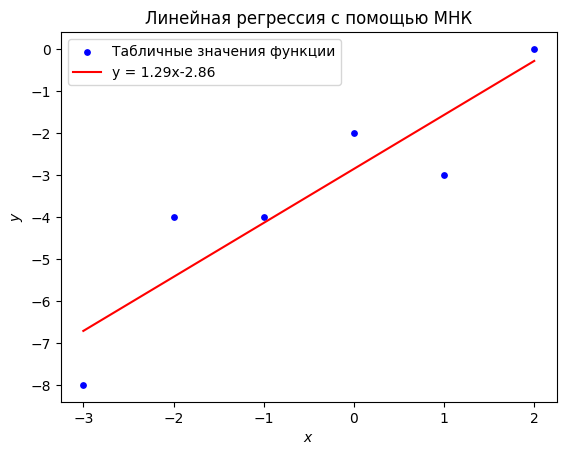

In [ ]:
x = np.array([-3, -2, -1,  0,  1, 2])
y = np.array([-8, -4, -4, -2, -3, 0])

graph_least_squares(x, y)

## Задача неточной интерполяции

В предыдущем разделе мы рассмотрели решение задачи линейной регрессии с помощью МНК. На практике число параметров $m$ в этой задаче обычно бывает небольшим. Дело в том, что в предметных областях, служащих источниками регрессионных задач, чаще всего используются двух- и трёхпараметрические модели. Трудно представить себе какую-то реальную, скажем, физическую модель, включающую, например, пять произвольных параметров, которые необходимо подбирать на основе экспериментальных данных. Очевидно, что теоретическое значение такой модели незначительно: имея "в руках" пять произвольных параметров, можно смоделировать практически что угодно. Что касается моделей с $m\geq 10$, то они совершенно бесполезны. Таким образом, **в задачах линейной регрессии** почти всегда $m=2$ или $m=3$.

Мы уже говорили, что в вычислительной математике МНК редко рассматривается как регрессионный метод; решение задач регрессии является, скорее, предметом статистики и анализа данных. С другой стороны, одно из центральных мест в вычислительной математике занимает **задача интерполяции**. Она ставится следующим образом.

Дана таблица значений $\big\{(x_i, y_i)\big\}_{i=0}^n$ (неизвестной) **функции-оригинала** $y=y(x)$. Требуется построить по этой таблице непрерывную **функцию-образ** $F=F(x)$ (**интерполянт**) так, чтобы $y_i=F(x_i)$. Более подробно с постановкой задачи интерполяции и методами её решения мы познакомимся на следующих семинарах. Пока отметим только, что весьма часто интерполянт $F=F(x)$ ищется в виде обобщённого полинома по некоторой системе базисных функций $\varphi_j(x)$ (далее нам будет удобнее нумеровать базисные функции и точки $x_i$, начиная с нуля):

$$F(x;\textbf{w})=\sum\limits_{j=0}^{m} w_j\varphi_j(x).$$

Принципиальное отличие этой задачи от задачи линейной регрессии состоит в **расстановке приоритетов**. Когда речь идёт о регрессии, то и количество, и вид базисных функций оказываются тесно связанными с моделью, поступающей из предметной области. Если физическая теория даёт, например, линейную по $x$ модель $F(x;a,b)=ax+b$ для зависимости $y=y(x)$, то нельзя просто так заменить эту модель какой-то другой моделью; нельзя взять, скажем, квадратичную по $x$ модель $F(x;a,b,c)=ax^2+bx+c$ и построить трёхпараметрическую регрессию. Подобная замена необоснованна, даже если вторая модель приводит к меньшему значению функционала $\text{RSS}$ по сравнению с первой моделью (т.е. даже если вторая кривая "ложится на точки" лучше первой). Цель регрессии — путём подгонки параметров найти наилучшую (например, в смысле минимизации функционала $\text{RSS}$) функцию **среди функций фиксированного вида**. При этом допускается, что эта наилучшая функция не будет строго удовлетворять всем условиям $y_i=F(x_i;\textbf{w})$ (часто она вообще не удовлетворяет ни одному из них — см. график из задачи 2). Иначе говоря, **в приоритете оказывается вид функции** $F(x_i;\textbf{w})$, потому что он диктуется некоторой моделью из предметной области.

Если же решается задача интерполяции, то **приоритетным является строгое выполнение всех условий** $y_i=F(x_i;\textbf{w})$. Вид функции $F$ и количество параметров $m$ при этом не конкретизируются: можно брать столько базисных функций $\varphi_j(x)$, сколько требуется, главное — воспроизвести всю таблицу значений $\big\{(x_i, y_i)\big\}_{i=0}^n$. Чтобы подчеркнуть это обстоятельство, сформулированную выше задачу интерполяции нередко называют задачей **точной** интерполяции.

Указанное различие важно чётко понимать во избежание подмены одной задачи другой. Известно, например, что при обработке результатов выполнения лабораторных работ по физике начинающие иногда выбирают для приближения экспериментальных точек полиномы высоких степеней, чтобы "кривая лучше легла на точки". Эта ошибка связана именно с неверной расстановкой приоритетов (задача регрессии подменяется задачей интерполяции): при обработке данных нет цели провести **какую-то** кривую так, чтобы охватить ею как можно больше точек, а есть цель построить **вполне определённую** кривую наилучшим образом (скажем, по МНК). Напротив, при интерполяции вид кривой не фиксируется, зато ставится задача провести кривую строго через **все** точки.


Бывает, однако, так, что методы точного интерполирования неприменимы: например, приближаемая функция не обладает достаточной гладкостью и для неё не удаётся построить интерполяционный полином или сплайн (что такое сплайн, мы узнаем на одном из следующих семинаров). В этом случае от требования удовлетворить всем условиям $y_i=F(x_i;\textbf{w})$ отказываются и формулируют какое-то другое требование — например, минимизировать тот же функционал $\text{RSS}$, что и в задаче линейной регрессии. Возникает задача **неточной интерполяции**. Внешне она тождественна с задачей линейной регрессии (основные формулы не меняются), но **существенное различие** всё же **остаётся**: в задаче регрессии параметров обычно два-три и вид базисных функций фиксирован, а в задаче неточной интерполяции система базисных функций и их количество априорно не регламентированы.

После сказанного может показаться, что для решения задачи неточной интерполяции достаточно применить тот же МНК, что и для построения линейной регрессии, т.е. достаточно последовательно выполнить следующие шаги:

* выбрать систему из $m<n$ базисных функций $\varphi_j(x)$ так, чтобы векторы $\boldsymbol{\varphi}_j$ были линейно независимыми,
* составить из столбцов $\boldsymbol{\varphi}_j$ матрицу $\textbf{G}_\varphi$,
* перейти от СЛАУ $\textbf{G}_\varphi\textbf{w}=\textbf{y}$ к симметризованной по Гауссу СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ с матрицей Грама $\boldsymbol{\Gamma}=\textbf{G}_\varphi^\text{T}\textbf{G}_\varphi$ и вектором правой части $\textbf{g}=\textbf{G}_\varphi^\text{T}\textbf{y}$,
* решить полученную СЛАУ; решение будет единственным в силу теоремы 1.

Этот алгоритм кажется привлекательным в силу своей простоты, и при вычислениях с бесконеными десятичными дробями он действительно применим. Однако нужно учесть одну особенность, связанную с выбором базисных функций $\varphi_j(x)$, существенно осложняющую решение задачи.

Дело в том, что при произвольном выборе функций $\varphi_j(x)$ СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ может оказаться очень плохо обусловленной; в этом случае её численное решение становится затруднительным. Так, упоминавшаяся выше система функций

$$1,\quad x,\quad x^2,\quad \dots,\quad x^p$$

уже при $p>5$ приводит к настолько плохо обусловленной системе, что её решение, найденное по МНК, не имеет смысла. В задаче линейной регрессии с этим затруднением обычно не сталкиваются, так как модели типа

$$F(x;\textbf{w})=w_0+w_1x+w_2x^2+w_3x^3+w_4x^4+w_5x^5$$

с шестью произвольными параметрами, как правило, не используются в качестве регрессионных (мы уже отмечали это в начале раздела). Однако в задаче неточной интерполяции нет какого-то принципиального ограничения на степень приближающего алгебраического полинома, что и объясняет возникновение трудности: **с увеличением степени интерполяционного многочлена ухудшается обусловленность СЛАУ, получаемой в МНК**. Этот эффект мы видели на первом семинаре, когда на конкретных примерах иллюстрировали важность знакомства с теорией численных методов (см. пример 2 из раздела "Введение").

Итак, **на практике при решении задачи неточной интерполяции с помощью МНК недостаточно требовать линейной независимости векторов** $\boldsymbol{\varphi}_j$: хотя единственный вектор весов $\textbf{w}$ и будет существовать, найти его численно с приемлемой точностью будет затруднительно в силу плохой обусловленности задачи. Решение этой проблемы подсказывается следующим наблюдением.

Заметим, что если векторы $\boldsymbol{\varphi}_j$ попарно ортогональны, т.е.

$$(\boldsymbol{\varphi}_k, \boldsymbol{\varphi}_l)=0,\quad k\neq l,$$

то матрица Грама $\boldsymbol{\Gamma}$ оказывается диагональной и решение СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ находится очень просто:

$$w_j=\frac{g_j}{\gamma_{jj}}=\frac{(\boldsymbol{\varphi}_j, \textbf{y})}{(\boldsymbol{\varphi}_j, \boldsymbol{\varphi}_j)}=\frac{\displaystyle\sum\limits_{i=0}^n\varphi_j(x_i)y_i}{\displaystyle\sum\limits_{i=0}^n\varphi_j^2(x_i)},\quad j=0,\,1,\,\dots,\,m.$$

Это наводит на мысль выбирать базисные функции $\varphi_j(x)$ так, чтобы система векторов $\boldsymbol{\varphi}_j$ была **ортогональна** (а значит, и линейно независима) или по крайней мере **близка к ортогональной**. Тогда матрица Грама окажется "почти диагональной" и обусловленность СЛАУ $\boldsymbol{\Gamma}\textbf{w}=\textbf{g}$ будет достаточно хорошей.

В качестве базисных функций, удовлетворяющих указанному условию, обычно рекомендуют выбирать некоторую систему **ортогональных многочленов**. В вычислительной математике широко применяются, например, **многочлены Чебышёва первого рода**. Они определяются формулой

$$T_k(x)=\cos(k\arccos{x}),\quad k=0,\,1,\,\dots,\quad x\in [-1,1].$$

Можно показать, что для этих функций справедливо рекуррентное соотношение

$$T_{k+1}(x)=2xT_k(x)-T_{k-1}(x).$$

Для наглядности выпишем несколько первых многочленов Чебышёва:

$$T_0(x)=1,\quad T_1(x)=x,\quad T_2(x)=2x^2-1,\quad T_3(x)=4x^3-3x,\quad T_4(x)=8x^4-8x^2+1.$$

Многочлены Чебышёва обладают целым рядом любопытных свойств (которые мы ещё будем обсуждать при рассмотрении точной интерполяции функций). В частности, они **ортогональны с весом** (в смысле скалярного произведения в пространстве вещественнозначных функций, интегрируемых с квадратом по Риману):

$$\int\limits_{-1}^{1}\frac{dx}{\sqrt{1-x^2}}\,T_k(x)\,T_l(x)=
  \begin{cases}
    0,&\quad k\neq l,\\
    \pi/2,&\quad k=l>0,\\
    \pi,&\quad k=l=0.
  \end{cases}$$

Наличие уже этого свойства приводит к лучшей обусловленности СЛАУ, получаемой при использовании МНК, хотя речь здесь идёт об ортогональности в непрерывном случае — для функций, — а не в интересующем нас дискретном случае — для векторов $\boldsymbol{\varphi}_j$, которые при $\varphi_j(x)=T_j(x)$ имеют компоненты $T_j(x_i)$.

При специальном выборе точек $\{x_i\}_{i=0}^n$ можно добиться ортогональности и в интересующем нас смысле:

$$\sum\limits_{i=0}^nT_k(x_i)\,T_l(x_i)=0,\quad k\neq l.$$

Оказывается, для этого надо взять в качестве узлов $\{x_i\}_{i=0}^n$ нули многочлена Чебышёва $(n+1)$-го порядка. Доказательство этого утверждения мы предоставляем читателю.

**Упражнение 2.** Известно, что нули любого многочлена Чебышёва действительны, различны и расположены на интервале $(-1,1)$. Обозначим нули многочлена Чебышёва $T_{n+1}(x)$ через $\xi_i$. Ясно, что их количество совпадает со степенью многочлена, т.е. равно $n+1$. Докажите, что

$$\frac{2}{n+1}\sum\limits_{i=0}^nT_k(\xi_i)\,T_l(\xi_i)=\delta_{kl},\quad k,\,l=0,\,1,\,\dots,\,n,$$

т.е. **многочлены Чебышёва ортогональны на нулях более старших многочленов**.

*Указание.* Из определения многочленов Чебышёва найдите формулу для нулей $\xi_i$ и получите с её помощью равенство вида $T_k(\xi_i)=\cos(\dots)$. Затем с помощью тригонометрических тождеств преобразуйте левую часть равенства из упражнения к виду

$$\#\sum\limits_{i=0}^n\cos(\dots)+\#\sum\limits_{i=0}^n\cos(\dots)$$

(знак $\#$ заменяет некий коэффициент). Выясните, при каких условиях на $k$ и $l$ получившиеся суммы обращаются в нуль. Для этого Вам понабится утверждение из следующего упражнения.

**Упражнение 3.** Докажите, что для любых натуральных $n$ и $N$, а также любого действительного $\varphi$ верно равенство

$$\sum\limits_{q=0}^n\exp\bigg(2\pi i\frac{qN}{n+1}+i\psi\bigg)=0.$$

Получите из этой формулы следствия для действительной и мнимой частей (при $N\neq 0$).

*Указание.* Рассмотрите комплексные корни уравнения $z^{n+1}=1$.

Помимо многочленов Чебышёва можно выбирать в качестве базисных функций $\varphi_j(x)$ и другие ортогональные многочлены (скажем, **многочлены Лежандра**). Мы не будем останавливаться на соответствующих примерах — читатель сможет найти их в книге П.К. Суетина "Классические ортогональные многочлены" (см. список литературы).

Итак, рядом приёмов (специальным выбором базисных функций и точек $\{x_i\}_{i=0}^n$) всё-таки можно добиться хорошей обусловленности задачи неточной интерполяции, решаемой с помощью МНК. Однако эти приёмы удобны далеко не всегда. В связи с этим в современной вычислительной практике часто используются другие методы приближения функций.

## МНК в Python

Библиотеки Python предлагают несколько реализаций МНК, ориентированных на решение различных задач.

Функция ```lstsq``` из модуля ```linalg``` библиотеки ```numpy``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)) позволяет находить обобщённые решения переопределённых СЛАУ. Она принимает на вход матрицу СЛАУ $\textbf{A}\in\text{Mat}_{n\times m}(\mathbb{R})$ и вектор правой части $\textbf{f}$ (длины $n$). Обобщённое решение ищется как вектор $\textbf{u}$ (длины $m$), доставляющий минимум евклидовой норме вектора $\textbf{A}\textbf{x}-\textbf{f}$. Заметим, что

$$||\textbf{A}\textbf{x}-\textbf{f}||_3=\sqrt{(\textbf{A}\textbf{x}-\textbf{f}, \textbf{A}\textbf{x}-\textbf{f})}=\sqrt{\Phi(\textbf{x})},$$

где $\Phi(\textbf{x})$ — целевой функционал, соответствующий переопределённой СЛАУ. Отсюда следует, что метод, реализуемый функцией ```lstsq```, представляет собой не что иное, как МНК (см. определения 2 и 3).

Функция ```lstsq``` возвращает не только найденный вектор $\textbf{u}$, но и минимальное значение функционала $\Phi(\textbf{x})$, которое достигается на этом векторе, а также ранг матрицы $\textbf{A}$ и вектор из её сингулярных чисел $\sigma_i$, упорядоченных по невозрастанию. Пример с переопределённой СЛАУ из задачи 1:


In [ ]:
import numpy as np

A = [ [1, 1],
      [2, 1],
      [1, 2] ]
f = [1, 2, 3]

np.linalg.lstsq(A, f)

(array([0.27272727, 1.27272727]),
 array([0.36363636]),
 np.int32(2),
 array([3.31662479, 1.        ]))

Ранг матрицы $\textbf{A}$ определяется по количеству ненулевых сингулярных чисел. При этом по желанию пользователя могут быть отброшены сингулярные числа, близкие к нулю: сигнатура функции предусматривает возможность передать необязательный аргумент ```rcond```, устанавливающий **относительный порог** для сингулярных чисел. Если $\sigma_i<\text{rcond}\cdot \sigma_\text{max}$ (где $\sigma_\text{max}$ — максимальное сингулярное число матрицы $\textbf{A}$), то при определении ранга это $\sigma_i$ будет рассматриваться как нулевое, т.е. **эффективный ранг** матрицы уменьшится. По умолчанию $\text{rcond}=\varepsilon_\text{маш}\cdot\max(n,m)$, т.е. если $n\geq m$, то $\text{rcond}=\varepsilon_\text{маш}\cdot n$ (чем больше уравнений содержит СЛАУ, тем выше порог).

Поясним, для каких целей может понадобиться изложенная выше процедура с "отсечением" сингулярных чисел и определением эффективного ранга. Дело в том, что функцию ```lstsq``` можно вызывать не только в случае $n>m$, отвечающем переопределённой СЛАУ, но и при $n=m$ (и даже при $n<m$, когда СЛАУ является недоопределённой). Очевидно, что при $n=m$ обобщённое решение СЛАУ $\textbf{u}$ совпадает с её классическим решением, причём $\Phi(\textbf{u})=0$.

Пусть решается СЛАУ

$$\begin{cases}
    (1-\varepsilon)x_1 + x_2=2-\varepsilon,\\
    x_1 + (1-\varepsilon)x_2=2-\varepsilon
  \end{cases}$$

(не являющаяся переопределённой). Ясно, что её точное решение есть единичный вектор. Попробуем найти это решение при различных $\varepsilon$ с помощью уже известной нам функции ```solve```:

In [ ]:
def eps_with_solve(eps: float):
    A = [ [1 - eps, 1],
          [1, 1 - eps] ]
    f = [2 - eps, 2 - eps]

    try:
        x = np.linalg.solve(A, f)
        return x
    except Exception as e:
        print(e)

Будем уменьшать величину $\varepsilon$, последовательно придавая ей значения $10^{-1}$, $10^{-2}$ и т.д. до $10^{-20}$:

In [ ]:
from ipywidgets import interact, FloatLogSlider

eps_w = FloatLogSlider(min=-20, max=-1, step=1, base=10, value=0.1)

interact(eps_with_solve, eps=eps_w);

interactive(children=(FloatLogSlider(value=0.1, description='eps', max=-1.0, min=-20.0, step=1.0), Output()), …

Начиная с $\varepsilon=10^{-17}$, функция ```solve``` выдаёт ошибку в связи с вырожденностью матрицы. Так получается потому, что при очень малых $\varepsilon$ строки (и столбцы) матрицы оказываются практически линейно зависимыми. На фоне неизбежных ошибок округления величина $\varepsilon$ теряется, в результате чего матрица рассматривается как вырожденная.

Если же подать указанную СЛАУ на вход функции ```lstsq```, то решение будет найдено верно при любом $\varepsilon$:

In [ ]:
def eps_with_lstsq(eps: float):
    A = [ [1 - eps, 1],
          [1, 1 - eps] ]
    f = [2 - eps, 2 - eps]

    return np.linalg.lstsq(A, f)
    # return np.linalg.lstsq(A, f, rcond=1e-10)

In [ ]:
eps_w = FloatLogSlider(min=-20, max=-1, step=1, base=10, value=0.1)

interact(eps_with_lstsq, eps=eps_w);

interactive(children=(FloatLogSlider(value=0.1, description='eps', max=-1.0, min=-20.0, step=1.0), Output()), …

Видно, что при $\varepsilon\leq 10^{-16}\sim\varepsilon_\text{маш}$ меньшее сингулярное число полагается равным нулю, а эффективный ранг матрицы уменьшается с двойки до единицы. При этом матрица СЛАУ автоматически приближается матрицей меньшего ранга путём "обрезки" матриц-сомножителей в сингулярном разложении $\textbf{A}=\textbf{U}\boldsymbol{\Sigma}\textbf{V}^\dagger$ (эту процедуру мы уже рассматривали во введении ко второму семинару). Таким образом, возникает, по существу, **недоопределённая СЛАУ** с $n=1$ и $m=2$. К ней применяется МНК, с помощью которого и находится верное решение. В приведённом примере аргумент ```rcond``` не задавался, и поэтому использовалось его значение по умолчанию. Увеличение этого параметра (например, до значения $10^{-10}$, как в комментированной строке) позволяет выполнить "переключение на меньший ранг" раньше, чем ошибки округления сравняются с $\varepsilon$. В некоторых задачах такой приём может оказаться полезным.

Подчеркнём, что **обобщённые решения** (в смысле определения 3) **существуют и у недоопределённых СЛАУ** ($n<m$), правда, **оказываются не единственными**. В подобных случаях функция ```lstsq``` возвращает то из обобщённых решений, которое имеет наименьшую евклидову норму. Пример:

In [ ]:
B = [ [1, 1, 1],
      [1, 1, 0] ]
b = [3, 2]

np.linalg.lstsq(B, b)

(array([1., 1., 1.]),
 array([], dtype=float64),
 np.int32(2),
 array([2.13577921, 0.66215345]))

Аналогичная функция с тем же именем ```lstsq``` имеется в модуле ```linalg``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)):

In [ ]:
import scipy as sp

sp.linalg.lstsq(A, f)

(array([0.27272727, 1.27272727]),
 np.float64(0.3636363636363639),
 2,
 array([3.31662479, 1.        ]))

Покажем, как можно применить функцию ```lstsq``` для построения линейной регрессии. Предварительно напишем функцию ```generate_data```, которая по заданной зависимости $f=f(x)$ строит $n$ точек с координатами $(x_i,f_i)$, а затем придаёт им случайные смещения (распределённые по нормальному закону) как вдоль оси абсцисс, так и вдоль оси ординат. Массивы случайных величин, выступающих в роли смещений, будем генерировать с помощью метода ```normal``` класса ```Generator``` ([документация](https://numpy.org/doc/stable/reference/random/generator.html)) из модуля ```random``` библиотеки ```numpy```. Для создания экземпляра класса требуется передать конструктору некоторый битовый генератор — например, конгруэнтный генератор с перестановкой, реализованный в виде функции ```np.random.PCG64``` ([документация](https://numpy.org/doc/stable/reference/random/bit_generators/pcg64.html)). Величины смещений точек будем регулировать, задавая дисперсии распределений:



In [ ]:
from types import FunctionType
import matplotlib.pyplot as plt

def generate_data(n: int, f: FunctionType,
                  shift_x: float = 0.5, shift_y: float = 0.5,
                  graph: bool = False):
    # линейная зависимость y=y(x)
    x = np.linspace(0, 10, n)
    func = np.vectorize(f)
    y = func(x)

    # наложение на точки случайных сдвигов
    gen = np.random.Generator(np.random.PCG64())
    x_shift = gen.normal(loc=0, scale=shift_x, size=n)
    y_shift = gen.normal(loc=0, scale=shift_y, size=n)
    x = x + x_shift
    y = y + y_shift

    # визуализация построенных данных
    if graph:
        fig, ax = plt.subplots()
        ax.scatter(x, y, s=10, c='b')

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")
        plt.title("Данные для линейной регрессии")
        plt.show()

    return x, y

Для примера возьмём квадратичную по $x$ функцию $f(x)=2x^2+3x+1$ (пользуясь терминологией из предыдущего раздела, можно сказать, что это функция-оригинал, которая на практике никогда не бывает известной). Сгенерируем 40 "экспериментальных точек" и для наглядности отобразим их на графике:

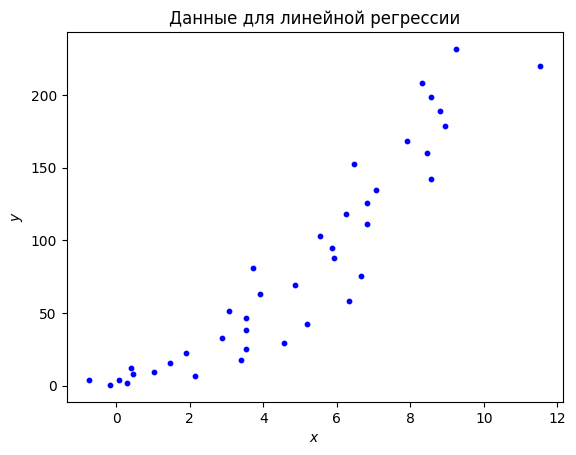

In [ ]:
f = lambda xi: 2 * xi**2 + 3 * xi + 1
x, y = generate_data(n=40, f=f, shift_x=1.0, shift_y=0.7, graph=True)

Заметим, между прочим, что из графика трудно установить степень полинома, соответствующего зависимости между $x$ и $y$: "на глаз" кажется, что данные можно приблизить и линейным законом. Подчеркнём ещё раз, что **конкретный вид используемой модели входит в формулировку задачи регрессии** (а она поступает из предметной области). Далее мы будем пользоваться трёхпараметрической моделью $F(x)=ax^2+bx+c$.

Мы видели, что, когда в качестве функции $F$ используется алгебраический полином, столбцы матрицы $\textbf{G}_\varphi$ переопределённой СЛАУ представляют собой степени $x^0$, $x^1$, $x^2$ и т.д., вычисленные в точках $\{x_i\}_{i=0}^n$. Для построения такой матрицы можно применить широко использующуюся в ```numpy``` **технику срезов** (документация: [первая ссылка](https://numpy.org/doc/stable/user/basics.indexing.html#slicing-and-striding), [вторая ссылка](https://numpy.org/doc/stable/user/basics.indexing.html#dimensional-indexing-tools)). Если дан одномерный массив, то можно формально взять срез по двум измерениям (```axis=0``` и ```axis=1```) с объектом ```None``` в качестве диапазона индексов столбцов. Такой вызов эквивалентен добавлению к массиву новой оси (нового измерения). В случае одномерного массива вектор-строка превратится в вектор-столбец:

In [ ]:
arr = np.array([1, 2, 3, 4, 5])
arr = arr[:, None]
arr

array([[1],
       [2],
       [3],
       [4],
       [5]])

Подобные конструкции применяются довольно часто, в связи с чем для объекта ```None``` даже создан специальный псевдоним ```np.newaxis``` ([документация](https://numpy.org/doc/stable/reference/constants.html#numpy.newaxis)). Его удобно использовать в коде — так программа становится более ясной:

In [ ]:
arr = np.array([1, 2, 3, 4, 5])
arr = arr[:, np.newaxis]
arr

array([[1],
       [2],
       [3],
       [4],
       [5]])

К получившемуся столбцу можно применить конструкцию вида ```arr • [l1, l2, ...]```, где точка означает некоторую бинарную операцию. В результате получится матрица с количеством столбцов, равным длине одномерного массива, причём ко всем элементам первого столбца будет применена бинарная операция ```•``` с элементом ```l1``` в качестве второго аргумента, ко всем элементам второго столбца — бинарная операция с элементом ```l2``` и т.д. Примеры:

In [ ]:
arr + [3, 5, 7]

array([[ 4,  6,  8],
       [ 5,  7,  9],
       [ 6,  8, 10],
       [ 7,  9, 11],
       [ 8, 10, 12]])

In [ ]:
arr < [3, 5, 7]

array([[ True,  True,  True],
       [ True,  True,  True],
       [False,  True,  True],
       [False,  True,  True],
       [False, False,  True]])

Очень легко, таким образом, создать копии столбцов с величинами $\{x_i\}_{i=0}^n$, возведёнными в целые неотрицательные степени, как это требуется в рассматриваемой задаче приближения алгебраическим полиномом. Например:

In [ ]:
arr ** [2, 3, 4]

array([[  1,   1,   1],
       [  4,   8,  16],
       [  9,  27,  81],
       [ 16,  64, 256],
       [ 25, 125, 625]])

Итак, программа для построения регрессии, использующая функцию ```lstsq```, может выглядеть так:

In [ ]:
def regr_poly2(x: np.ndarray, y: np.ndarray):
    # подбор коэффициентов по МНК
    G = x[:, np.newaxis] ** [0, 1, 2]
    w, Phi, rank, sing = np.linalg.lstsq(G, y)

    # построение регрессионной кривой
    F = lambda xi: w[0] + w[1] * xi + w[2] * xi**2
    func = np.vectorize(F)
    grid = np.arange(np.floor(np.min(x)), np.ceil(np.max(x)) + 0.01, 0.01)
    regr_line = func(grid)

    # предыдущий блок можно реализовать так:
    # grid = np.arange(np.floor(np.min(x)), np.ceil(np.max(x)) + 0.01, 0.01)
    # regr_line = np.polyval(np.flip(w), grid)

    # визуализация
    fig, ax = plt.subplots()
    ax.scatter(x, y, s=10, c='b', label='Данные') # данные
    ax.plot(grid, regr_line, c='g',
            label='y = {:.2f}$x^2${:+.2f}$x${:+.2f}'.format(w[2], w[1], w[0])) # подобранная кривая

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend()

    plt.title("Линейная регрессия в модели $y=ax^2+bx+c$")

    plt.show()

При построении регрессионной кривой можно было бы вычислить значения найденного алгебраического полинома с помощью функции ```np.polyval``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polyval.html)). Она принимает на вход массив коэффициентов полинома (начиная с коэффициента при старшей степени) и сетку, в узлах которой необходимо найти значения полинома. Поскольку в нашей программе принят другой порядок коэффициентов в векторе $\textbf{w}$ (от нулевой степени к старшей), перед подачей этого вектора в функцию ```np.polyval``` мы применили функцию ```np.flip``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.flip.html)) для реверсии массива.

Результат работы программы:

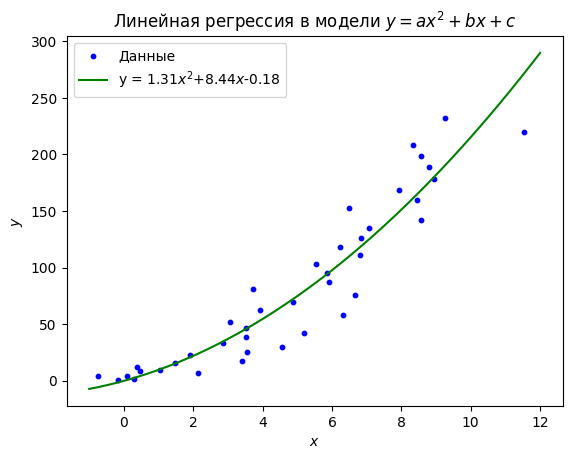

In [ ]:
regr_poly2(x, y)

Тот же результат (те же параметры $a$, $b$ и $c$) можно было бы получить с помощью функции ```np.polyfit``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html)). Она принимает на вход два массива, образующих таблицу данных $\big\{(x_i, y_i)\big\}_{i=0}^n$, и степень алгебраического полинома, который необходимо использовать в качестве регрессионной модели:

In [ ]:
np.polyfit(x, y, 2)

array([ 1.31024332,  8.43634514, -0.18126748])

Если передать необязательный аргумент ```full=True```, то кроме подобранных параметров будет выведена дополнительная информация о результатах применения МНК:

In [ ]:
np.polyfit(x, y, 2, full=True)

(array([ 1.31024332,  8.43634514, -0.18126748]),
 array([20851.28322182]),
 np.int32(3),
 array([1.64043348, 0.53953549, 0.13371407]),
 np.float64(8.881784197001252e-15))

Как и в случае функции ```lstsq```, вывод содержит минимальное значение целевого функционала, эффективный ранг матрицы переопределённой СЛАУ, а также список её сингулярных чисел. Последним выведен относительный порог ```rcond```.

Функция ```np.polyfit``` является в некотором смысле устаревшей, хотя до сих пор используется весьма широко. Современные версии библиотеки ```numpy``` содержат специальный пакет ```polynomial``` ([документация](https://numpy.org/doc/stable/reference/routines.polynomials-package.html)), включающий шесть классов для приближения функций обобщёнными полиномами с помощью МНК. Каждый класс строит обобщённый полином по некоторой системе классических многочленов:

* класс ```Polynomial``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html)) реализует приближения алгебраическими полиномами (отрезками степенных рядов),
* класс ```Chebyshev``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.chebyshev.Chebyshev.html)) реализует приближения обобщёнными полиномами по системе ортогональных многочленов Чебышёва (первого рода),
* класс ```Legendre``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.legendre.Legendre.html)) — то же с многочленами Лежандра,
* класс ```Laguerre``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.laguerre.Laguerre.html)) — то же с многочленами Лагерра,
* классы ```Hermite``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite.Hermite.html)) и ```HermiteE``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite_e.HermiteE.html)) — то же с многочленами Эрмита.

Два класса для многочленов Эрмита введены в связи с тем, что на практике эти многочлены одинаково часто используют в двух различных видах (эквивалентных с принципиальной точки зрения):

$$\text{H}_n(x)=(-1)^ne^{x^2}\frac{d^n}{dx^n}e^{-x^2},\quad \text{He}_n(x)=(-1)^ne^{x^2/2}\frac{d^n}{dx^n}e^{-x^2/2}.$$

Первое определение часто встречается в теоретической физике, второе — в статистике. Обозначение $\text{He}_n(x)$ характерно, скорее, для англоязычной литературы.



Выполним с помощью пакета ```polynomial``` "фит" ранее сгенерированных данных. Как и выше, выбираем регрессионную в модель в виде алгебраического полинома второй степени (класс ```Polynomial```):

In [ ]:
F = np.polynomial.Polynomial.fit(x, y, 2)
F

Polynomial([ 83.49754485, 138.49908993,  49.30662883], domain=[-0.73819105, 11.53073854], window=[-1.,  1.], symbol='x')

Пользоваться приближающим многочленом в таком виде не очень удобно. Преобразование к стандартному виду осуществляется методом ```convert``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.convert.html)):

In [ ]:
F = F.convert()
F

Polynomial([-0.18126748,  8.43634514,  1.31024332], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Для получения массива коэффициентов надо обратиться к атрибуту ```coef``` созданного экземпляра класса ```Polynomial```:

In [ ]:
F.coef

array([-0.18126748,  8.43634514,  1.31024332])

Этот вызов эквивалентен применению функции ```np.polyfit``` к исходным данным (только коэффициенты многочлена выдаются в другом порядке — начиная с нулевой степени). На практике лучше отдавать предпочтение именно классу ```Polynomial```, поскольку использованная в нём реализация МНК характеризуется лучшей численной устойчивостью.

Очень удобно, что все шесть классов из пакета ```polynomial``` содержат методы анализа обобщённых полиномов. При необходимости, можно, например, найти корни построенного полинома (метод ```roots``` — [документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.roots.html)):

In [ ]:
F.roots()

array([-6.46017746,  0.02141527])

Доступны также его дифференцирование (метод ```deriv``` — [документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.deriv.html)) и интегрирование (метод ```integ``` — [документация](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.integ.html)):

In [ ]:
dF = F.deriv(1)
dF.convert()

Polynomial([8.43634514, 2.62048663], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [ ]:
integ_F = F.integ(1, 2026) # второй аргумент - произвольная постоянная интегрирования
integ_F.convert()

Polynomial([ 2.02600000e+03, -1.81267483e-01,  4.21817257e+00,  4.36747772e-01], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Для более подробного ознакомления с возможностями пакета ```polynomial``` рекомендуем обратиться к документации, на которую мы ссылались выше.

Полезно знать, что и сами обобщённые многочлены (Чебышёва, Лежандра и др.) также имеют готовые реализации в Python. Их можно найти в модуле ```special``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/special.html)) наряду с большим количеством других специальных функций. Приведём ссылку на раздел документации, посвящённый именно ортогональным многочленам: [ссылка](https://docs.scipy.org/doc/scipy/reference/special.html#orthogonal-polynomials). Познакомиться с этим разделом читатель сможет самостоятельно. Мы ограничимся только указанием на весьма полезную функцию, позволяющую получить массив корней обобщённого многочлена заданной степени. Для примера возьмём многочлен Чебышёва пятой степени:

In [ ]:
roots, weights = sp.special.roots_chebyt(5)
roots

array([-0.95105652, -0.58778525,  0.        ,  0.58778525,  0.95105652])

Функция ```roots_chebyt``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.roots_chebyt.html)) выдаёт не только нули многочлена $T_n(x)$, но и веса для так называемой квадратурной формулы Гаусса—Чебышёва (это метод численного интегрирования). В контексте задачи неточной интерполяции нас интересуют именно нули. Элементы полученного массива ```roots``` можно использовать в качестве точек $\{x_i\}_{i=0}^n$ (если, конечно, при построении приближения функции-оригинала есть возможность распоряжаться выбором этих точек). В предыдущем разделе мы уже говорили, в чём заключается достоинство такой системы узлов.

Для наглядности приведём также графики нескольких первых многочленов Чебышёва. Заодно продемонстрируем использование функции ```eval_chebyt``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.eval_chebyt.html)), предназначенной для вычисления значений многочлена $T_n(x)$ заданной степени $n$ в указанной точке (или точках):

In [ ]:
def graph_Chebyshev_polynomials(k: int):
    grid = np.arange(-1, 1 + 0.01, 0.01)

    fig, ax = plt.subplots()

    for i in range(k):
        y = sp.special.eval_chebyt(i, grid)
        ax.plot(grid, y, label=i)

        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    ax.legend(title="Степень $n$", loc="upper left", bbox_to_anchor=(1, 1))

    plt.title("Графики многочленов Чебышёва $y=T_n(x)$")

    plt.show()

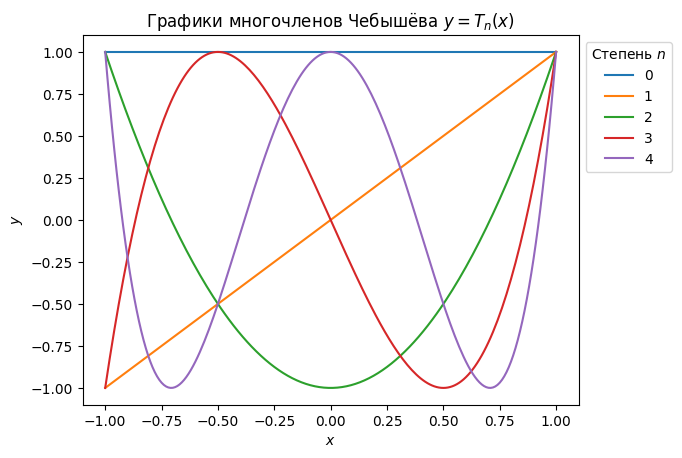

In [ ]:
graph_Chebyshev_polynomials(5)

В связи с упоминанием функции ```eval_chebyt``` отметим, что **вызов этой функции** (и аналогичных функций для других многочленов, в том числе "обычных" алгебраических) **всегда следует предпочитать вычислению значения многочлена "вручную"**. Пусть, например, требуется найти значение многочлена Чебышёва $T_{n}(x)$ в точке $x=a$. Можно было бы сначала получить коэффициенты этого многочлена с помощью атрибута ```c``` класса ```np.poly1d``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html)), экземпляром которого является объект, выдаваемый функцией ```sp.special.chebyt``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.chebyt.html)), а потом найти искомую величину $T_n(a)$, умножив степени $a$ на полученные коэффициенты:

In [ ]:
def calc_Chebyshev(n: int, a: float):
    degs = [ a**i for i in range(n+1) ]
    coeffs = sp.special.chebyt(n).c

    return coeffs @ np.flip(degs)

Однако такой способ расчёта оказывается численно неустойчивым, особенно при высоких степенях многочлена $n$. Убедимся в этом так: будем вычислять значения $T_n(1)$ при различных $n$ и сравнивать результаты работы пользовательской функции ```calc_Chebyshev``` с результатами, полученными функцией ```eval_chebyt```. Из свойств многочленов Чебышёва следует, что для всех степеней $n$ должно иметь место равенство $T_n(1)=1$.

In [ ]:
def compare_Chebyshev(n: int):
    print("Вычисление вручную: ", calc_Chebyshev(n, a=1))
    print("Вычисление с помощью встроенной функции: ", sp.special.eval_chebyt(n, 1))

In [ ]:
from ipywidgets import IntSlider

n_w = IntSlider(min=0, max=100, step=1, value=0)

interact(compare_Chebyshev, n=n_w);

interactive(children=(IntSlider(value=0, description='n'), Output()), _dom_classes=('widget-interact',))

Встроенные классы для работы с многочленами позволяют избежать подобных эффектов; они обеспечивают численную устойчивость вплоть до степеней $n\sim 10^4$. Об этом следует помнить и при работе с "обычными" алгебраическими многочленами: их лучше задавать в виде объектов упоминавшегося выше класса ```sp.polynomial.Polynomial``` (или более старого класса ```np.poly1d```), а не собирать "вручную" по коэффициентам.

Рассмотренные до сих пор реализации МНК относились к библиотеке ```numpy```. Функции, так или иначе связанные с МНК, содержит и библиотека ```scipy``` (точнее — её модуль ```optimize```). Мы не будем перечислять все такие функции: с ними можно познакомиться по [документации](https://docs.scipy.org/doc/scipy/reference/optimize.html#least-squares-and-curve-fitting). Ограничимся примером построения **нелинейной** регрессии с помощью функции ```sp.optimize.curve_fit``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)). В качестве данных возьмём таблицу результатов измерения индукции $B$ магнитного поля в зависимости от напряжённости поля $H$ (таблица заимствована из условия задачи, сформулированной в видеоразборе метода итерированного веса; мы рекомендовали посмотреть это видео в одном из предыдущих разделов — дублируем [ссылку](https://vkvideo.ru/video-212608323_456239026)).

In [ ]:
H = np.array([   8,   10,   15,   20,   30,   40,   60,   80])
B = np.array([13.0, 14.0, 15.4, 16.3, 17.2, 17.8, 18.5, 18.8])

Чтобы "фитировать" эти данные нелинейной по параметрам зависимостью

$$B=\frac{H}{a+bH},$$

достаточно передать в ```curve_fit``` эту функцию и два массива с данными:

In [ ]:
def B_func(H: float, a: float, b: float):
    return H / (a + b*H)

def regr_nonlin(x: np.ndarray, y: np.ndarray):
    # подбор параметров нелинейным МНК
    w, pcov = sp.optimize.curve_fit(B_func, H, B)

    # построение регрессионной кривой
    F = lambda xi: xi / (w[0] + w[1] * xi)
    func = np.vectorize(F)
    grid = np.arange(np.floor(np.min(x)), np.ceil(np.max(x)) + 0.01, 0.01)
    regr_line = func(grid)

    # визуализация
    fig, ax = plt.subplots()
    ax.scatter(x, y, s=10, c='b', label='Экспериментальные точки')
    ax.plot(grid, regr_line, c='magenta',
            label='B=H/({:.2f}{:+.2f}H)'.format(w[0], w[1]))

    ax.set_xlabel("$H/H_0$")
    ax.set_ylabel("$B/B_0$")
    ax.legend(loc="lower right")

    plt.title(r"Зависимость индукции $B$ магнитного поля"
              "\n"
              r"от его напряжённости $H$")

    plt.show()

In [ ]:
regr_nonlin(H, B)

ValueError: 
Зависимость индукции $$B$$ магнитного поля
                     ^
ParseException: Expected end of text, found '$'  (at char 21), (line:1, col:22)

<Figure size 640x480 with 1 Axes>

Обсуждение (итерационного) метода, стоящего за функцией ```curve_fit``` (по сути, нелинейного МНК), потребовало бы от нас довольно пространного изложения основ теории оптимизации. Эта тема выходит за рамки семинара. Желающих познакомиться с теоретическими основами нелинейного МНК отсылаем к специальной литературе — например, к неплохой брошюре "Methods for Non-Linear Least Squares Problems" (см. список дополнительной литературы).

# Часть вторая — Аппроксимация зашумлённых данных

Предполагается, что читатель знает
* определение QR-разложения матрицы $\textbf{A}$,
* основные понятия теории вероятностей и статистики (математическое ожидание, дисперсия, матрица, ковариаций и т.п.).

## Постановка задачи

Пусть значения независимой переменной $\{x_i\}_{i=1}^n$ известны точно, а измеренные значения $\{y_i\}_{i=1}^n$ имеют вид

$$
y_i=f(x_i)+\varepsilon_i,\qquad i=1,\,\ldots,\,n,
$$

где $f=f(x)$ — неизвестная зависимость, а $\varepsilon_i$ — шум (погрешности измерений). В простейшей модели

$$
\mathbb{E}\boldsymbol{\varepsilon}=\textbf{0},\qquad
\operatorname{cov}(\boldsymbol{\varepsilon})=\sigma^2\textbf{E}.
$$

Через $\mathbb{E}$ и $\operatorname{cov}$ здесь обозначены математическое ожидание и матрица ковариаций соответственно; $\sigma>0$ — некоторое число. Сделанные предположения означают, что шум не имеет систематического смещения, разные измерения некоррелированы и имеют одинаковую дисперсию (определяемую величиной $\sigma$). Подчеркнём, что гауссовость шума (нормальность распределения) для вычисления МНК-оценки не требуется; она необходима для построения классических доверительных интервалов и проверки статистических гипотез.

Выберем пространство приближающих функций

$$
V_m=\operatorname{span}\{\varphi_1,\,\varphi_2\,\ldots,\,\varphi_m\},\qquad
p(x;\textbf{c})=\sum_{j=1}^m c_j\varphi_j(x)\in V_m.
$$

Под $\textbf{c}$ понимается вектор коэффициентов (параметров регрессии). Составим матрицу $\textbf{G}_\varphi=(g_{ij})\in\text{Mat}_{n\times m}$, $g_{ij}=\varphi_j(x_i)$. Мы видели, что в "обычном" МНК коэффициенты $c_j$ определяются из условия

$$
\widehat{\textbf{c}}=
\underset{\textbf{c}\,\in\,\mathbb{R}^m}{\operatorname{argmin}}
\Vert\textbf{G}_\varphi\textbf{c}-\textbf{y}\Vert_3^2.
$$

Обратим внимание на последовательность действий, выполняемых при постановке задачи: сначала выбирают допустимый класс функций $V_m$, пользуясь физической моделью или априорной информацией, и только затем подбирают коэффициенты $c_j$. Разумеется, наличие шума приводит к тому, что результат аппроксимации зависит не только от вида зависимости $f=f(t)$, но и от свойств шума $\boldsymbol{\varepsilon}$.


## Ортогональная проекция. Баланс ошибки

Предположим, что столбцы матрицы $\textbf{G}_\varphi$ линейно независимы. По найденному с помощью МНК вектору коэффициентов $\widehat{\textbf{c}}$ можно определить вектор $\widehat{\textbf{y}}$ значений построенного приближения:

$$
\widehat{\textbf{y}}=\textbf{G}_\varphi\widehat{\textbf{c}}
=\textbf{P}\textbf{y},\qquad
\textbf{P}=\textbf{G}_\varphi(\textbf{G}_\varphi^{\text{T}}\textbf{G}_\varphi)^{-1}\textbf{G}_\varphi^{\text{T}}.
$$

Оператор $\textbf{P}$ есть ортогональный проектор на пространство столбцов матрицы $\textbf{G}_\varphi$ (т.е. на пространство $V_m$). Поэтому невязка $\textbf{r}=\textbf{y}-\widehat{\textbf{y}}=\textbf{y}-\textbf{P}\textbf{y}$ удовлетворяет условию

$$
\textbf{G}^{\text{T}}\textbf{r}=\textbf{0}.
$$

Формула, выражающая $\textbf{P}$ через $\textbf{G}_\varphi$, нужна необходима для теоретического анализа; на практике ни матрица $(\textbf{G}^{\text{T}}\textbf{G})^{-1}$, ни проектор явно не вычисляются.

Обозначим через $\textbf{f}$ вектор, составленный из величин $f(x_i)$ (т.е. вектор точных значений функции $f=f(x)$ в выбранных узлах $\{x_i\}_{i=1}^n$). Из соотношения $\textbf{y}=\textbf{f}+\boldsymbol{\varepsilon}$ следует, что

$$
\widehat{\textbf{y}}-\textbf{f}
=-(\textbf{E}-\textbf{P})\textbf{f}+\textbf{P}\boldsymbol{\varepsilon}.
$$

Первое слагаемое — **ошибка модели**; она зависит от выбора пространства $V_m$ (т.е. выбора базисных функций $\varphi=\varphi(x)$). Второе слагаемое — часть шума, попавшая в это пространство. Поскольку эти векторы-слагаемые ортогональны друг другу, при $\operatorname{cov}(\boldsymbol{\varepsilon})=\sigma^2\textbf{E}$

$$
\mathbb{E}\|\widehat{\textbf{y}}-\textbf{f}\|_3^2
=\|(\textbf{E}-\textbf{P})\textbf{f}\|_3^2+\sigma^2\operatorname{tr}\textbf{P}
=\|(\textbf{E}-\textbf{P})\textbf{f}\|_3^2+\sigma^2m.
$$

Для вложенной последовательности пространств $V_1\subset V_2\subset\ldots$ первый вклад в выписанную норму не возрастает, а второй растёт (поскольку увеличивается размерность пространства $m$). Можно сказать, что требуется найти компромисс между слишком простой моделью и **переобучением**.

Компоненты невязки $r_i=y_i-p(x_i;\widehat{\textbf{c}})$ называются **остатками**. **Остаточная сумма квадратов** (residual sum of squares, RSS) — это

$$
\operatorname{RSS}=\sum_{i=1}^n r_i^2=\sum_{i=1}^n\big(y_i-p(x_i;\widehat{\textbf{c}})\big)^2=\|\textbf{y}-\widehat{\textbf{y}}\|_3^2.
$$

Она характеризует суммарное квадратичное расхождение модели с теми данными, по которым подбирались коэффициенты $c_j$. При увеличении $m$ прежнее приближение остаётся допустимым частным случаем более сложной модели, поэтому минимальное значение функционала $\operatorname{RSS}$ не может увеличиться. Однако его уменьшение может быть связано не только с лучшим описанием истинной зависимости $f=f(x)$, но и с подгонкой под случайный шум $\boldsymbol{\varepsilon}$. Поэтому выбирать степень полинома, руководствуясь только значением $\operatorname{RSS}$, нельзя.

## Неопределённость коэффициентов регрессии

Если истинная зависимость $f=f(x)$ принадлежит выбранному пространству $V_m$, то существует вектор $\textbf{c}^*\in\mathbb{R}^m$ такой, что $\textbf{f}=\textbf{G}_\varphi\textbf{c}^*$ и

$$
\mathbb{E}\widehat{\textbf{c}}=\textbf{c}^*.
$$
При этом
$$
\operatorname{cov}(\widehat{\textbf{c}})
=\sigma^2(\textbf{G}_\varphi^{\text{T}}\textbf{G})^{-1}.
$$

Если дисперсия шума $\sigma$ неизвестна, используется оценка

$$
s^2=\frac{\Vert\textbf{y}-\textbf{G}_\varphi\widehat{\textbf{c}}\Vert_3^2}{n-m}.
$$

Для вектора базисных функций $\boldsymbol{\varphi}(x)=(\varphi_1(x),\ldots,\varphi_m(x))^{\text{T}}$ дисперсия оценки среднего значения модели есть

$$
\operatorname{var}\widehat{p}(x)=
\sigma^2\boldsymbol{\varphi}(x)^{\text{T}}
(\textbf{G}_\varphi^{\text{T}}\textbf{G}_\varphi)^{-1}\boldsymbol{\varphi}(x).
$$

Дисперсия нового наблюдения в той же точке содержит дополнительное слагаемое $\sigma^2$. Поэтому **доверительный интервал для среднего отклика** у́же, чем **предсказательный интервал для нового измерения**. Первый описывает неопределённость положения средней зависимости $\mathbb{E}[y| x]$, то есть самой регрессионной кривой в выбранной точке $x$. Второй описывает возможные значения отдельного будущего измерения в той же точке. Помимо неопределённости положения кривой он должен учитывать собственную случайную погрешность нового измерения, поэтому и оказывается шире. Эти формулы имеют смысл только при согласованной модели шума и выбранного пространства; малые остатки сами по себе не доказывают правильность модели.


## Выбор модели и вычислительная устойчивость

Практическая схема вычислений может быть следующей.

1. Выбрать базис и сложность модели из содержательных соображений. Если такой информации недостаточно, отделить часть данных для проверки или использовать перекрёстную проверку.

2. Исследовать остатки $r_i=y_i-p(x_i;\widehat{\textbf{c}})$. Например, построить график $r_i$ в зависимости от $x_i$ или от рассчитанных значений $\widehat{y}_i$. По горизонтальной оси такого графика откладывают $x_i$ или $\widehat{y}_i$, а по вертикальной — соответствующий остаток $r_i$. Здесь не изменяют одно и то же наблюдение: сравнивают остатки для разных точек выборки, последовательно расположенных слева направо. Для адекватной модели точки должны располагаться вокруг нуля без заметного систематического рисунка и иметь примерно одинаковый вертикальный разброс. Тренд, изгиб или волна указывают на то, что модель не описала часть закономерной зависимости. О том же говорит ситуация, когда несколько соседних по $x_i$ точек подряд оказываются только выше нуля или только ниже нуля. Если вертикальный разброс различается в разных частях графика, дисперсия шума, вероятно, непостоянна. Например, при малых $x_i$ остатки могут находиться в узкой полосе около нуля, а при больших $x_i$ — в заметно более широкой; тогда график напоминает расширяющуюся воронку. Это означает, что разные наблюдения имеют неодинаковую точность, и может потребоваться взвешенный МНК.

3. Масштабировать переменную и применить численно устойчивый базис. Для полиномиальной аппроксимации удобны многочлены Чебышёва на отрезке $[-1,1]$.

4. Условие минимума для $\Vert\textbf{G}_\varphi\textbf{c}-\textbf{y}\Vert_3^2$ приводит к квадратной СЛАУ — **нормальным уравнениям**

   $$
   \textbf{G}_\varphi^{\text{T}}\textbf{G}_\varphi\widehat{\textbf{c}}
   =\textbf{G}_\varphi^{\text{T}}\textbf{y}.
   $$

   Однако решать задачу МНК посредством явного построения и непосредственного решения этой системы обычно нецелесообразно. При полном столбцовом ранге матрицы $\textbf{G}_\varphi$

   $$
   \mu(\textbf{G}_\varphi^{\text{T}}\textbf{G}_\varphi)=\mu(\textbf{G}_\varphi)^2,
   $$

   то есть число обусловленности матрицы нормальных уравнений (в евклидовой норме) равно квадрату числа обусловленности исходной матрицы. Поэтому ошибки округления могут существенно усилиться. На практике задачу МНК решают с помощью QR-разложения или сингулярного разложения, не строя матрицу $\textbf{G}_\varphi^{\text{T}}\textbf{G}_\varphi$ явно. Для этого можно использовать, например, рассмотренную выше функцию `numpy.linalg.lstsq`.

5. Оценить качество модели на данных, которые не использовались при подборе коэффициентов, либо на нескольких независимых реализациях шума в вычислительном эксперименте.

Следующая демонстрация показывает, что ошибка на обучающих точках монотонно уменьшается с ростом степени приближающего полинома, а ошибка относительно истинной функции возрастает, начиная с некоторого момента.

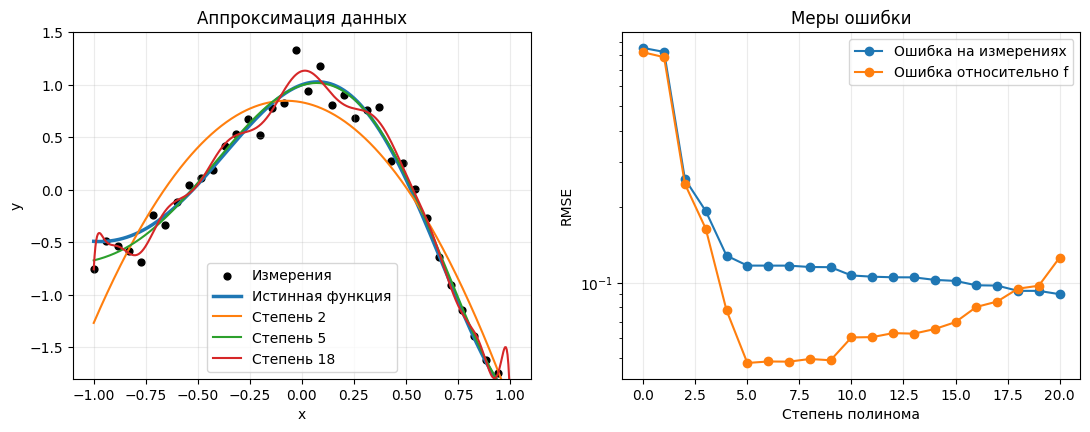

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebvander

# фиксируем генератор случайных чисел, чтобы результат воспроизводился
rng_noise = np.random.default_rng(2025)

# задаём узлы измерений, истинную функцию и стандартное отклонение шума
# истинная функция известна только в вычислительном эксперименте: она нужна,
# чтобы отдельно оценить качество аппроксимации между узлами
x_noise = np.linspace(-1.0, 1.0, 36)
f_noise = lambda x: np.exp(0.7 * x) * np.cos(3.0 * x)
sigma_noise = 0.12

# получаем одну реализацию зашумлённых данных
y_noise = f_noise(x_noise) + rng_noise.normal(0.0, sigma_noise, size=x_noise.size)

# на плотной сетке будем сравнивать аппроксимацию с истинной функцией
grid_noise = np.linspace(-1.0, 1.0, 500)
degrees = np.arange(0, 21)
train_rmse = []
truth_rmse = []
coefficients = {}

for degree in degrees:
    # матрица G содержит значения T_0(x), ..., T_degree(x),
    # где T_k — многочлены Чебышёва
    G = chebvander(x_noise, degree)

    # находим коэффициенты полинома данной степени методом наименьших квадратов
    coefficients[degree] = np.linalg.lstsq(G, y_noise, rcond=None)[0]

    # ошибка на тех же зашумлённых точках, по которым подбирались коэффициенты
    train_rmse.append(np.sqrt(np.mean((G @ coefficients[degree] - y_noise) ** 2)))

    # ошибка относительно истинной функции на плотной сетке
    G_grid = chebvander(grid_noise, degree)
    truth_rmse.append(
        np.sqrt(np.mean((G_grid @ coefficients[degree] - f_noise(grid_noise)) ** 2))
    )

# слева показываем несколько найденных аппроксимаций, справа — две меры ошибки
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(x_noise, y_noise, s=24, color="black", label="Измерения")
axes[0].plot(grid_noise, f_noise(grid_noise), linewidth=2.5, label="Истинная функция")

for degree in (2, 5, 18):
    approximation = chebvander(grid_noise, degree) @ coefficients[degree]
    axes[0].plot(grid_noise, approximation, label=f"Степень {degree}")

axes[0].set_ylim(-1.8, 1.5)

axes[0].set_title("Аппроксимация данных")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[0].grid(alpha=0.25)

axes[0].legend()

# RMSE на измерениях обычно убывает, но это не гарантирует улучшения модели:
# ошибка относительно истинной функции после некоторой степени может расти
axes[1].plot(degrees, train_rmse, "o-", label="Ошибка на измерениях")
axes[1].plot(degrees, truth_rmse, "o-", label="Ошибка относительно f")

axes[1].set_title("Меры ошибки")
axes[1].set_xlabel("Степень полинома")
axes[1].set_ylabel("RMSE")
axes[1].set_yscale("log")

axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()

## Неодинаковая точность измерений. Взвешенный МНК

Пусть погрешности независимы, но $\operatorname{var}\varepsilon_i=\sigma_i^2$. Тогда измерения с меньшей дисперсией должны сильнее влиять на результат. Взвешенный МНК минимизирует функционал

$$
\sum_{i=1}^n\frac{\big(p(x_i;\textbf{c})-y_i\big)^2}{\sigma_i^2}
=\Vert\textbf{W}^{1/2}(\textbf{G}_\varphi\textbf{c}-\textbf{y})\Vert_3^2,\qquad
\textbf{W}=\operatorname{diag}(\sigma_1^{-2},\ldots,\sigma_n^{-2}).
$$

Здесь

$$
\textbf{W}^{1/2}=\operatorname{diag}(\sigma_1^{-1},\ldots,\sigma_n^{-1})
$$

— диагональная матрица, квадрат которой равен $\textbf{W}$. Умножение на $\textbf{W}^{1/2}$ делит $i$-ю строку матрицы $\textbf{G}_\varphi$ и $i$-ю компоненту вектора $\textbf{y}$ на $\sigma_i$. Поэтому взвешенный МНК сводится к "обычному" МНК для матрицы $\textbf{W}^{1/2}\textbf{G}_\varphi$ и вектора $\textbf{W}^{1/2}\textbf{y}$.

Если известна полная матрица ковариаций $\boldsymbol{\Sigma}$, то минимизируется квадратичная форма

$$
(\textbf{G}_\varphi\textbf{c}-\textbf{y})^{\text{T}}
\boldsymbol{\Sigma}^{-1}(\textbf{G}_\varphi\textbf{c}-\textbf{y}).
$$

Вес $1/\sigma_i^2$ следует из модели погрешностей, а не выбирается для того, чтобы получить визуально более точную кривую. При верной ковариационной модели взвешенная оценка имеет меньшую дисперсию в среднем по повторным экспериментам, но в одной конкретной реализации не обязана оказываться более близкой к истинным параметрам.


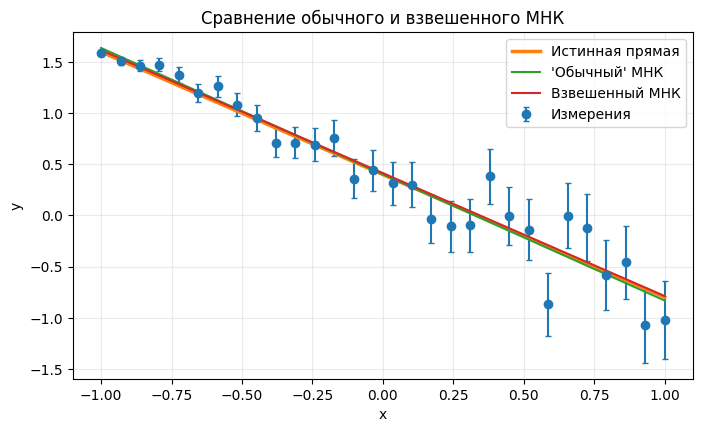

Истинные коэффициенты:  [ 0.4 -1.2]
'Обычный' МНК:  [ 0.40305112 -1.23534739]
Взвешенный МНК:  [ 0.41424596 -1.20272152]


In [ ]:
# фиксируем генератор случайных чисел для воспроизводимости примера
rng_wls = np.random.default_rng(2003)
x_wls = np.linspace(-1.0, 1.0, 30)

# стандартное отклонение шума растёт вместе с x: правые точки менее точны
sigma_wls = 0.03 + 0.35 * (x_wls + 1.0) / 2.0

# строим матрицу G для линейной модели вида c_0 + c_1 x
true_coefficients = np.array([0.4, -1.2])
G_wls = np.column_stack((np.ones_like(x_wls), x_wls))

# генерируем измерения с неодинаковой дисперсией шума
y_wls = G_wls @ true_coefficients + rng_wls.normal(0.0, sigma_wls)

# "обычный" МНК считает все наблюдения одинаково точными
coef_ols = np.linalg.lstsq(G_wls, y_wls, rcond=None)[0]

# во взвешенном МНК делим i-ю строку G и y_i на sigma_i
# это и есть умножение системы на W^{1/2}
coef_wls = np.linalg.lstsq(G_wls / sigma_wls[:, None], y_wls / sigma_wls, rcond=None)[0]

# вычисляем обе найденные прямые на плотной сетке для построения графика
grid_wls = np.linspace(-1.0, 1.0, 300)
G_grid_wls = np.column_stack((np.ones_like(grid_wls), grid_wls))

plt.figure(figsize=(8, 4.5))

# вертикальные отрезки показывают одно стандартное отклонение sigma_i
plt.errorbar(x_wls, y_wls, yerr=sigma_wls, fmt="o", capsize=2, label="Измерения")
plt.plot(grid_wls, G_grid_wls @ true_coefficients, linewidth=2.5, label="Истинная прямая")

plt.plot(grid_wls, G_grid_wls @ coef_ols, label="'Обычный' МНК")
plt.plot(grid_wls, G_grid_wls @ coef_wls, label="Взвешенный МНК")

plt.title("Сравнение обычного и взвешенного МНК")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(alpha=0.25)

plt.legend()

plt.show()

# сравниваем коэффициенты c_0 и c_1 для конкретной реализации шума
print("Истинные коэффициенты: ", true_coefficients)
print("'Обычный' МНК: ", coef_ols)
print("Взвешенный МНК: ", coef_wls)

## Область применимости модели

При постановке задачи предполагалось, что погрешность сосредоточена в значениях $y_i$, а узлы $x_i$ известны точно. Если заметные случайные ошибки есть и в $x_i$, обычный МНК решает уже не ту задачу. В зависимости от принятой модели погрешностей применяют модели ошибок в переменных (учитывают неточность измерения и $x_i$, и $y_i$), ортогональную регрессию (измеряют отклонение точки от модели по обеим координатам) или **полный МНК** (TLS — total least squares). В последнем случае допускают поправки и к матрице $\textbf{G}_\varphi$, и к вектору $\textbf{y}$.

Для ортогональной регрессии в Python можно использовать пакет [`odrpack`](https://hugomvale.github.io/odrpack-python/). Часто встречается также модуль [`scipy.odr`](https://docs.scipy.org/doc/scipy/reference/odr.html), однако начиная с ```scipy 1.17``` он считается устаревшим; актуальная документация ```scipy``` рекомендует переходить на `odrpack`. Теория и алгоритмы изложены в руководстве [ODRPACK](https://docs.scipy.org/doc/external/odrpack_guide.pdf), а полный МНК подробно рассмотрен в монографии Ван Хаффела и Вандевалле, указанной в списке литературы.

Отдельная проблема — выбросы. В нашем рассмотрении **остаток** $r_i=y_i-p(x_i;\widehat{\textbf{c}})$ — это разность между измеренным значением $y_i$ и значением, рассчитанным по построенной модели в той же точке $x_i$. Чем больше $|r_i|$, тем дальше наблюдение расположено от регрессионной кривой по вертикали. В целевой функционал остаток входит как $r_i^2$, поэтому увеличение его модуля в десять раз увеличивает вклад наблюдения в сто раз. Из-за этого один грубо ошибочный результат может заметно сместить найденные коэффициенты. Удалять наблюдение только потому, что оно не согласуется с ожидаемой кривой, нельзя: сначала проверяют экспериментальную причину, а при необходимости используют устойчивые методы и явно описывают правило обработки данных.

---

# Практические задачи

## Задача A


Написать программу, которая принимает на вход координаты $n\geq 4$ точек плоскости и с помощью МНК строит по ним окружность. Визуализировать результат. Пользоваться встроенными реализациями МНК запрещается.

## Задача B


Для данных из демонстрации, приведённой во второй части семинара, повторить вычислительный эксперимент по $N=200$ независимым реализациям шума.

1. Для степеней от $0$ до $20$ найти среднюю ошибку относительно истинной функции на густой сетке.

2. Сравнить полученную зависимость с ошибкой на исходных измерениях.

3. Повторить эксперимент для двух других значений $\sigma$ и объяснить, как меняется оптимальная степень.

4. Сравнить решение через `numpy.linalg.lstsq` с решением нормальных уравнений. При какой степени становится заметно различие?


# Литература и другие источники

## К части первой

**Видеозаписи:**

1. Вычислительная математика — лекция 6. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/BUTUuvs724M?si=Dflbqjl2AdyGauPC&t=3) (YouTube).

2. Метод наименьших квадратов — видеоразбор темы. Преподаватель — Г.С. Гойман. [Ссылка](https://vkvideo.ru/video-212608323_456239031) (VK Видео).

3. Итерационный взвешенный метод наименьших квадратов — видеоразбор задачи. Преподаватель — Н.И. Караваева. [Ссылка](https://vkvideo.ru/video-212608323_456239026) (VK Видео).

**Рекомендуемая литература (с комментариями):**

МНК рассматривается во многих книгах, однако в подавляющем большинстве источников упор делается на статистическую сторону вопроса (что, вообще говоря, не лишено оснований). **В рамках курса вычислительной математики** МНК лучше всего разобран в перечисленных ниже учебниках.

1. *Е.А. Волков. Численные методы.* Основные сведения по МНК (в том числе и разбор вопроса об оценке его погрешности статистическими методами) собраны в параграфах 13—14 первой главы (стр. 75—102) и излагаются в самодостаточной форме (в книгу включены необходимые определения и теоремы из линейной алгебры и гармонического анализа). Правда, ничего не говорится о переопределённых СЛАУ. Упомянуто несколько конкретных примеров ортогональных многочленов.

2. *А.А. Амосов, Ю.А. Дубинский, Н.В. Копченова. Вычислительные методы для инженеров.* МНК рассматривается в 13 параграфе главы 11 (стр. 343—356). Как и в учебнике Е.А. Волкова, используются элементы математической статистики.

3. *А.И. Лобанов, И.Б. Петров. Вычислительная математика: курс лекций.* Переопределённым СЛАУ и МНК посвящена отдельная лекция (третья, стр. 76—86), покрывающая в целом тот же материал, что и текст семинара. Интересно, что в конце лекции разъяснено происхождение матрицы Гильберта, служащей классическим примером плохо обусловленной матрицы. Напомним, что помимо указанного учебника существует книга тех же авторов с похожим названием: "Лекции по вычислительной математике" (издание 2006 г.). Лучше пользоваться названной выше книгой (издания 2021 г.). В более новом учебнике устранены замеченные опечатки, а материал отдельных лекций значительно переработан.

4. *П.К. Суетин. Классические ортогональные многочлены.* Многочленам Чебышёва посвящена третья глава книги (стр. 75—115).

5. *Р.С. Пастушков. Задачи и упражнения по вычислительной математике. V семестр. Решения, указания, ответы.* Пособие содержит всего четыре задачи, относящиеся к первой теме семинара: 2.22, 2.23, 2.25, 2.26 (стр. 14—15) — номер 2.24 почему-то отсутствует. Переопределённые СЛАУ и МНК представлены полнее — в задачах 3.1—3.14 (стр. 16—24). Параллельно на конкретных примерах рассматриваются многочлены Чебышёва. Напомним, что это пособие есть в библиотеке МФТИ. В электронном виде его легче всего скачать с сайта О.А. Пырковой (см. ниже).

6. *K. Madsen, H.B. Nielsen, O. Tingleff. Methods for Non-Linear Least Squares Problems.* Брошюра Датского технического университета, посвящённая нелинейному МНК. Простое и доступное изложение на английском языке с предварительными сведениями по некоторым методам оптимизации. Скачать брошюру можно по [ссылке](https://www2.imm.dtu.dk/pubdb/edoc/imm3215.pdf).

**Электронные ресурсы:**

1. Scikit-learn. Машинное обучение в Python. Замечательный сайт с огромным количеством полезной информации по основным аспектам анализа данных и машинного обучения в Python. Рассматриваются в том числе задача регрессии и МНК. [Ссылка.](https://scikit-learn.ru/stable/index.html)

2. Nonlinear Least Squares Regression for Python — статья на блоге Нэда Чарльза (университет Сиднея). Подробное обсуждение функций для построения нелинейной регрессии из модуля ```optimize``` библиотеки ```scipy```. Много ссылок на другие ресурсы. [Ссылка.](https://nedcharles.com/regression/Nonlinear_Least_Squares_Regression_For_Python.html)

3. Алгоритм Левенберга—Марквардта для нелинейного метода наименьших квадратов и его реализация на Python — статья на портале "Хабр". Посвящена, скорее, различным методам оптимизации, однако представляет интерес и в свете изучения нелинейного МНК. [Ссылка.](https://habr.com/ru/articles/308626/)

4. Вычислительная линейная алгебра — сайт с учебными материалами для 1 курса бакалавриата ФПМИ МФТИ. Много полезной информации по темам, далеко выходящим за рамки стандартных курсов. Много демонстраций на Python. [Ссылка.](https://nla360.fmin.xyz/)

5. Персональный сайт преподавателя МФТИ О.А. Пырковой. Содержит много полезных материалов по различным математическим курсам МФТИ. Страница с материалами осеннего семестра по вычислительной математике: [ссылка](https://www.pyrkovaoa-fizteh.ru/консультация-вычм-5/).

6. Scientific Python Lectures. Очень полезный ресурс, представляющий собой учебник по научному программированию на языке Python. Представлено много различных библиотек. Есть pdf-версия. Все материалы на английском языке. [Ссылка.](https://lectures.scientific-python.org/)

7. Python Programming And Numerical Methods: A Guide For Engineers And Scientists. Прекрасный сайт, представляющий собой электронную версию одноимённой книги по научному программированию на Python. Исключительно подробное изложение с многочисленными примерами. [Ссылка.](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html)


## К части второй

**Рекомендуемая литература (с комментариями):**

1. *Å. Björck. Numerical Methods for Least Squares Problems. 2nd ed.* SIAM, 2024. Глава 1 содержит математические и статистические основы МНК; последующие главы посвящены устойчивым вычислительным методам. [Страница книги.](https://epubs.siam.org/doi/book/10.1137/1.9781611977950)

2. *G.H. Golub, C.F. Van Loan. Matrix Computations. 4th ed.* Johns Hopkins University Press, 2013. Глава 5: ортогонализация и задачи МНК. [Страница книги.](https://www.press.jhu.edu/books/title/10678/matrix-computations)

3. *D.C. Montgomery, E.A. Peck, G.G. Vining. Introduction to Linear Regression Analysis. 6th ed.* Wiley, 2021. Модель линейной регрессии, анализ остатков, взвешенный МНК и выбор модели. [Страница книги.](https://www.wiley.com/en-us/Introduction%2Bto%2BLinear%2BRegression%2BAnalysis%2C%2B6th%2BEdition-p-9781119578758)

4. *G.A.F. Seber, A.J. Lee. Linear Regression Analysis. 2nd ed.* Wiley, 2003. Главы 3, 5 и 7: оценивание, доверительные интервалы и полиномиальная регрессия. [Страница книги.](https://onlinelibrary.wiley.com/doi/book/10.1002/9780471722199)

5. *S. Weisberg. Applied Linear Regression. 4th ed.* Wiley, 2014. Систематическое изложение линейной регрессии, диагностики модели по остаткам, доверительных и предиктивных интервалов. [Страница книги.](https://www.wiley.com/en-br/Applied%2BLinear%2BRegression%2C%2B4th%2BEdition-p-9781118386088)

6. *P.J. Huber, E.M. Ronchetti. Robust Statistics. 2nd ed.* Wiley, 2009. Классическая монография об устойчивом оценивании и чувствительности квадратичных критериев к выбросам; вопросам регрессии посвящена глава 7. [Страница книги.](https://onlinelibrary.wiley.com/doi/book/10.1002/9780470434697)

7. *P.T. Boggs, R.H. Byrd, J.E. Rogers, R.B. Schnabel. User’s Reference Guide for ODRPACK Version 2.01: Software for Weighted Orthogonal Distance Regression.* NISTIR 4834, 1992. Постановка взвешенной ортогональной регрессии и описание алгоритмов ODRPACK. [Руководство.](https://docs.scipy.org/doc/external/odrpack_guide.pdf)

8. *S. Van Huffel, J. Vandewalle. The Total Least Squares Problem: Computational Aspects and Analysis.* SIAM, 1991. Классическая монография по полному МНК, в котором погрешности допускаются и в матрице, и в правой части линейной системы. [Страница книги.](https://epubs.siam.org/doi/book/10.1137/1.9781611971002)

# Контрольные вопросы

## К части первой

1. Какие СЛАУ называются переопределёнными? Чем они отличаются от "обычных" СЛАУ?
2. Какая матрица называется весовой? Как определяется скалярное произведение с весовой матрицей?
3. Напишите формулу для целевого функционала, соответствующего переопределённой СЛАУ.
4. Какой вектор называется обобщённым решением переопределённой СЛАУ? Почему метод его поиска называется методом наименьших квадратов?
5. Сформулируйте теорему о существовании и единственности обобщённого решения переопределённой СЛАУ.
6. В чём заключается задача регрессии?
7. Чем отличается линейная регрессия от нелинейной? Является ли модель $F(x;a,b,c)=ax^2+bx+c$ линейной?
8. В чём разница между регрессионным МНК и МНК, использующимся для решения переопределённых СЛАУ?
9. Что такое обобщённый полином? базисные функции? вектор весов?
10. Опишите алгоритм построения линейной регрессии с помощью МНК. Какому условию должны удовлетворять базисные функции $\varphi_j(x)$? Приведите пример системы функций, удовлетворяющей этому условию.
11. Чем отличаются задачи линейной регрессии и (точной) интерполяции? В чём состоит задача неточной интерполяции?
12. Какая трудность возникает при решении задачи неточной интерполяции с помощью МНК? Как её можно преодолеть?

## К части второй

13.  Как записывается модель наблюдений с аддитивным шумом? Какие предположения приводят к обычному МНК?
14.  В чём заключается интерпретация МНК с точки зрения ортогонального проектирования? Какому условию ортогональности удовлетворяет невязка?
15.  Из каких двух слагаемых состоит средняя квадратичная ошибка аппроксимации в узлах? Как это объясняет переобучение?
16.  Почему остаточная сумма квадратов на исходных данных не подходит как единственный критерий выбора степени полинома?
17.  Когда следует применять взвешенный МНК и почему естественными весами являются $1/\sigma_i^2$?
18.  Почему решение системы нормальных уравнений, к которой сводится задача МНК, может быть менее устойчивым, чем решение задачи МНК с помощью QR-разложения или сингулярного разложения?
19.  Чем отличаются доверительный интервал для среднего отклика и предсказательный интервал для нового измерения?
20.  Почему "обычный" МНК неприменим без оговорок, если заметные погрешности присутствуют и в $x_i$?
